# Heart Disease Prediction Using Machine Learning

**Student:** Bathuka Shivashankar  
**Student ID:** 24071919  
**Module:** 7PAM2002 - MSc Data Science Individual Project  
**Semester:** B 2025/2026  
**University:** University of Hertfordshire

---

## Project Overview

### Problem Statement

Cardiovascular disease remains the leading cause of mortality worldwide, with early detection being crucial for effective treatment and improved patient outcomes. This project aims to develop machine learning models to predict the presence of heart disease in patients based on clinical and demographic features.

**Research Question:**  
*Can machine learning models effectively predict the likelihood of heart disease in patients based on clinical and demographic features, and which risk factors are most significant in determining heart disease presence?*

**Objectives:**
1. Perform comprehensive exploratory data analysis on the Cleveland Heart Disease dataset
2. Implement data preprocessing techniques (missing value treatment, feature engineering)
3. Develop and compare multiple classification models (Logistic Regression, Random Forest, SVM, Gradient Boosting)
4. Evaluate model performance using appropriate metrics (accuracy, precision, recall, ROC-AUC)
5. Identify key predictive features through feature importance analysis
6. Compare results with existing literature and provide clinical interpretation

---

## Dataset Information

### Source
**Dataset:** Cleveland Heart Disease Dataset  
**Repository:** UCI Machine Learning Repository  
**URL:** https://archive.ics.uci.edu/dataset/45/heart+disease  
**File Used:** processed.cleveland.data  
**Donated:** June 30, 1988  
**Creators:** Andras Janosi, William Steinbrunn, Matthias Pfisterer, Robert Detrano

### Data Collection
The dataset was collected from four locations:
1. **Cleveland Clinic Foundation** (Ohio, USA) - Primary dataset used in this project
2. Hungarian Institute of Cardiology (Budapest, Hungary)
3. University Hospital (Zurich, Switzerland)
4. V.A. Medical Center (Long Beach, California, USA)

The data was collected from patients who underwent cardiac catheterization (angiography), which is the gold standard for diagnosing coronary artery disease.

### Dataset Characteristics
- **Total Records:** 303 patients
- **Total Features:** 13 independent variables + 1 target variable
- **Feature Types:** Mixed (categorical, integer, continuous)
- **Missing Values:** Minimal (< 2%)
- **Target Variable:** Binary classification (0 = no disease, 1 = disease present)

---

## Feature Descriptions

| # | Feature | Description | Type | Values/Range |
|---|---------|-------------|------|--------------|
| 1 | **age** | Age in years | Continuous | 29-77 years |
| 2 | **sex** | Gender | Binary Categorical | 0 = Female, 1 = Male |
| 3 | **cp** | Chest pain type | Ordinal Categorical | 1 = Typical angina<br>2 = Atypical angina<br>3 = Non-anginal pain<br>4 = Asymptomatic |
| 4 | **trestbps** | Resting blood pressure (on admission) | Continuous | 94-200 mm Hg |
| 5 | **chol** | Serum cholesterol | Continuous | 126-564 mg/dl |
| 6 | **fbs** | Fasting blood sugar > 120 mg/dl | Binary Categorical | 0 = False, 1 = True |
| 7 | **restecg** | Resting electrocardiographic results | Ordinal Categorical | 0 = Normal<br>1 = ST-T wave abnormality<br>2 = Left ventricular hypertrophy |
| 8 | **thalach** | Maximum heart rate achieved | Continuous | 71-202 bpm |
| 9 | **exang** | Exercise induced angina | Binary Categorical | 0 = No, 1 = Yes |
| 10 | **oldpeak** | ST depression induced by exercise relative to rest | Continuous | 0-6.2 |
| 11 | **slope** | Slope of peak exercise ST segment | Ordinal Categorical | 1 = Upsloping<br>2 = Flat<br>3 = Downsloping |
| 12 | **ca** | Number of major vessels colored by fluoroscopy | Ordinal | 0-3 vessels |
| 13 | **thal** | Thalassemia test result | Nominal Categorical | 3 = Normal<br>6 = Fixed defect<br>7 = Reversible defect |
| 14 | **target** | Heart disease diagnosis (original) | Target | 0 = No disease<br>1-4 = Disease severity |
| 15 | **target_binary** | Heart disease presence (created) | Target | 0 = No disease<br>1 = Disease present |

### Target Variable Transformation

The original target variable has 5 classes (0-4) representing disease severity:
- **0:** No presence of heart disease (< 50% diameter narrowing)
- **1-4:** Increasing severity of heart disease (> 50% diameter narrowing)

For this binary classification project, I created **target_binary**:
- **0 (No Disease):** Original value = 0
- **1 (Disease Present):** Original values = 1, 2, 3, or 4

**Rationale:** Binary classification aligns with clinical decision-making where the primary concern is detecting disease presence rather than severity classification.

---

## Clinical Context

### Key Clinical Measurements Explained

**Chest Pain Types (cp):**
- **Typical Angina:** Classic heart-related chest pain triggered by exertion, relieved by rest
- **Atypical Angina:** Chest pain with some but not all characteristics of angina
- **Non-anginal Pain:** Chest pain unlikely related to heart
- **Asymptomatic:** No chest pain symptoms

**ST Depression (oldpeak) and Slope:**
- ST segment changes on ECG during exercise indicate inadequate blood flow to heart muscle
- Greater ST depression and flat/downsloping patterns suggest ischemia (reduced blood flow)

**Thalassemia (thal):**
- Blood disorder affecting hemoglobin production
- Fixed defect: Permanent perfusion abnormality
- Reversible defect: Temporary perfusion abnormality indicating ischemia

**Fluoroscopy (ca):**
- Number of major coronary arteries (0-3) with visible blockage
- More vessels affected = more severe disease

---

## Ethical Considerations

**Data Privacy:**
- Patient names and social security numbers were removed from the original dataset
- All data is anonymized and publicly available for research purposes
- Dataset licensed under Creative Commons Attribution 4.0 International (CC BY 4.0)

**Ethical Approval:**
- This project uses pre-existing, publicly available, anonymized data
- No University of Hertfordshire ethics approval required (no new data collection or human participants)
- Original data collection obtained appropriate informed consent from participants

**Data Source Credibility:**
- Data collected by reputable medical institutions
- Published in peer-reviewed journal (American Journal of Cardiology, 1989)
- Widely used benchmark dataset in machine learning research

---

## Project Methodology Overview

1. **Data Loading & Exploration**
   - Load Cleveland dataset from UCI repository
   - Initial data quality assessment
   - Descriptive statistics and data structure analysis

2. **Data Preprocessing**
   - Handle missing values (mode imputation for ca and thal)
   - Data type conversion (categorical vs. numerical)
   - Create binary target variable
   - Feature encoding and scaling

3. **Exploratory Data Analysis (EDA)**
   - Distribution analysis for all features
   - Correlation analysis
   - Feature-target relationship visualization
   - Outlier detection

# Let's Begin!


1: DATA EXPLORATION & UNDERSTANDING


1.1: Load and Inspect the Dataset

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load the cleveland.data file with proper encoding
# Note: This file has no headers and uses '?' for missing values
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Column names based on UCI documentation
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'target'
]

# Load the data with Latin-1 encoding and handle missing values
df = pd.read_csv(url, names=column_names, encoding='latin-1', na_values='?')

# Display basic information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\nDataset Shape: {df.shape}")
print(f"Number of Records: {df.shape[0]}")
print(f"Number of Features: {df.shape[1] - 1}")  # -1 for target
print(f"Target Variable: 'target' (0-4 scale)")


DATASET OVERVIEW

Dataset Shape: (303, 14)
Number of Records: 303
Number of Features: 13
Target Variable: 'target' (0-4 scale)


In [2]:
print("\n" + "=" * 60)
print("FIRST 10 ROWS OF DATA")
print("=" * 60)
print(df.head(10))



FIRST 10 ROWS OF DATA
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   
5  56.0  1.0  2.0     120.0  236.0  0.0      0.0    178.0    0.0      0.8   
6  62.0  0.0  4.0     140.0  268.0  0.0      2.0    160.0    0.0      3.6   
7  57.0  0.0  4.0     120.0  354.0  0.0      0.0    163.0    1.0      0.6   
8  63.0  1.0  4.0     130.0  254.0  0.0      2.0    147.0    0.0      1.4   
9  53.0  1.0  4.0     140.0  203.0  1.0      2.0    155.0    1.0      3.1   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0 

In [3]:

print("\n" + "=" * 60)
print("LAST 5 ROWS OF DATA")
print("=" * 60)
print(df.tail())




LAST 5 ROWS OF DATA
      age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
298  45.0  1.0  1.0     110.0  264.0  0.0      0.0    132.0    0.0      1.2   
299  68.0  1.0  4.0     144.0  193.0  1.0      0.0    141.0    0.0      3.4   
300  57.0  1.0  4.0     130.0  131.0  0.0      0.0    115.0    1.0      1.2   
301  57.0  0.0  2.0     130.0  236.0  0.0      2.0    174.0    0.0      0.0   
302  38.0  1.0  3.0     138.0  175.0  0.0      0.0    173.0    0.0      0.0   

     slope   ca  thal  target  
298    2.0  0.0   7.0       1  
299    2.0  2.0   7.0       2  
300    2.0  1.0   7.0       3  
301    2.0  1.0   3.0       1  
302    1.0  NaN   3.0       0  


In [4]:
print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
print(df.info())



DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None


In [5]:

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)



DATA TYPES
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object


In [6]:

print("\n" + "=" * 60)
print("BASIC STATISTICS")
print("=" * 60)
print(df.describe())



BASIC STATISTICS
              age         sex          cp    trestbps        chol         fbs  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  303.000000   
mean    54.438944    0.679868    3.158416  131.689769  246.693069    0.148515   
std      9.038662    0.467299    0.960126   17.599748   51.776918    0.356198   
min     29.000000    0.000000    1.000000   94.000000  126.000000    0.000000   
25%     48.000000    0.000000    3.000000  120.000000  211.000000    0.000000   
50%     56.000000    1.000000    3.000000  130.000000  241.000000    0.000000   
75%     61.000000    1.000000    4.000000  140.000000  275.000000    0.000000   
max     77.000000    1.000000    4.000000  200.000000  564.000000    1.000000   

          restecg     thalach       exang     oldpeak       slope          ca  \
count  303.000000  303.000000  303.000000  303.000000  303.000000  299.000000   
mean     0.990099  149.607261    0.326733    1.039604    1.600660    0.672241   
std      

In [7]:

print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage': missing_percent
})
print(missing_df[missing_df['Missing Count'] > 0])



MISSING VALUES CHECK
      Missing Count  Percentage
ca                4    1.320132
thal              2    0.660066


In [8]:

print("\n" + "=" * 60)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 60)
target_dist = df['target'].value_counts().sort_index()
print(target_dist)
print(f"\nTotal samples: {target_dist.sum()}")



TARGET VARIABLE DISTRIBUTION
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Total samples: 303


In [9]:
print("\n" + "=" * 60)
print("UNIQUE VALUES PER COLUMN")
print("=" * 60)
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


UNIQUE VALUES PER COLUMN
age: 41 unique values
sex: 2 unique values
cp: 4 unique values
trestbps: 50 unique values
chol: 152 unique values
fbs: 2 unique values
restecg: 3 unique values
thalach: 91 unique values
exang: 2 unique values
oldpeak: 40 unique values
slope: 3 unique values
ca: 4 unique values
thal: 3 unique values
target: 5 unique values


2: DATA PREPROCESSING & CLEANING

2.1: Understanding Features & Creating Data Dictionary

In [10]:

# ============================================================================
# STEP 2.1: FEATURE UNDERSTANDING & DATA DICTIONARY
# (Using the df that's already in memory)
# ============================================================================

print("=" * 80)
print("STEP 2.1: FEATURE UNDERSTANDING & DATA DICTIONARY")
print("=" * 80)

# Create a comprehensive data dictionary
data_dict = {
    'Feature': ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
    'Description': [
        'Age in years',
        'Sex (1 = male, 0 = female)',
        'Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic)',
        'Resting blood pressure (mm Hg on admission)',
        'Serum cholesterol (mg/dl)',
        'Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)',
        'Resting ECG results (0: normal, 1: ST-T wave abnormality, 2: left ventricular hypertrophy)',
        'Maximum heart rate achieved',
        'Exercise induced angina (1 = yes, 0 = no)',
        'ST depression induced by exercise relative to rest',
        'Slope of peak exercise ST segment (1: upsloping, 2: flat, 3: downsloping)',
        'Number of major vessels colored by fluoroscopy (0-3)',
        'Thalassemia (3: normal, 6: fixed defect, 7: reversible defect)',
        'Heart disease diagnosis (0: no disease, 1-4: increasing severity)'
    ],
    'Type': ['Continuous', 'Binary Categorical', 'Ordinal Categorical', 'Continuous',
             'Continuous', 'Binary Categorical', 'Ordinal Categorical', 'Continuous',
             'Binary Categorical', 'Continuous', 'Ordinal Categorical', 'Ordinal Categorical',
             'Nominal Categorical', 'Target (Ordinal)'],
    'Range': ['29-77', '0-1', '1-4', '94-200', '126-564', '0-1', '0-2',
              '71-202', '0-1', '0-6.2', '1-3', '0-3', '3,6,7', '0-4']
}

dict_df = pd.DataFrame(data_dict)
print("\n DATA DICTIONARY:")
print(dict_df.to_string(index=False))



STEP 2.1: FEATURE UNDERSTANDING & DATA DICTIONARY

 DATA DICTIONARY:
 Feature                                                                                   Description                Type   Range
     age                                                                                  Age in years          Continuous   29-77
     sex                                                                    Sex (1 = male, 0 = female)  Binary Categorical     0-1
      cp Chest pain type (1: typical angina, 2: atypical angina, 3: non-anginal pain, 4: asymptomatic) Ordinal Categorical     1-4
trestbps                                                   Resting blood pressure (mm Hg on admission)          Continuous  94-200
    chol                                                                     Serum cholesterol (mg/dl)          Continuous 126-564
     fbs                                         Fasting blood sugar > 120 mg/dl (1 = true, 0 = false)  Binary Categorical     0-1
 restecg    Re

In [11]:
# Analyze each feature
print("\n" + "=" * 80)
print("DETAILED FEATURE ANALYSIS")
print("=" * 80)

for col in df.columns:
    print(f"\n Feature: {col.upper()}")
    print(f"   Data Type: {df[col].dtype}")
    print(f"   Missing Values: {df[col].isnull().sum()} ({(df[col].isnull().sum()/len(df)*100):.2f}%)")
    print(f"   Unique Values: {df[col].nunique()}")

    if df[col].nunique() <= 10:  # Categorical or ordinal with few values
        print(f"   Value Counts:")
        print(df[col].value_counts().sort_index().to_string().replace('\n', '\n      '))
    else:  # Continuous
        print(f"   Min: {df[col].min():.2f}, Max: {df[col].max():.2f}, Mean: {df[col].mean():.2f}, Median: {df[col].median():.2f}")




DETAILED FEATURE ANALYSIS

 Feature: AGE
   Data Type: float64
   Missing Values: 0 (0.00%)
   Unique Values: 41
   Min: 29.00, Max: 77.00, Mean: 54.44, Median: 56.00

 Feature: SEX
   Data Type: float64
   Missing Values: 0 (0.00%)
   Unique Values: 2
   Value Counts:
sex
      0.0     97
      1.0    206

 Feature: CP
   Data Type: float64
   Missing Values: 0 (0.00%)
   Unique Values: 4
   Value Counts:
cp
      1.0     23
      2.0     50
      3.0     86
      4.0    144

 Feature: TRESTBPS
   Data Type: float64
   Missing Values: 0 (0.00%)
   Unique Values: 50
   Min: 94.00, Max: 200.00, Mean: 131.69, Median: 130.00

 Feature: CHOL
   Data Type: float64
   Missing Values: 0 (0.00%)
   Unique Values: 152
   Min: 126.00, Max: 564.00, Mean: 246.69, Median: 241.00

 Feature: FBS
   Data Type: float64
   Missing Values: 0 (0.00%)
   Unique Values: 2
   Value Counts:
fbs
      0.0    258
      1.0     45

 Feature: RESTECG
   Data Type: float64
   Missing Values: 0 (0.00%)
   Unique V

In [12]:
# Check for duplicate rows
print("\n" + "=" * 80)
print("DATA QUALITY CHECKS")
print("=" * 80)
print(f"Duplicate Rows: {df.duplicated().sum()}")
print(f"Total Missing Values: {df.isnull().sum().sum()}")



DATA QUALITY CHECKS
Duplicate Rows: 0
Total Missing Values: 6


In [13]:

# Target variable analysis
print("\n" + "=" * 80)
print("TARGET VARIABLE ANALYSIS")
print("=" * 80)
print("\nOriginal Target Distribution (5 classes):")
print(df['target'].value_counts().sort_index())
print(f"\nClass 0 (No Disease): {(df['target'] == 0).sum()} ({(df['target'] == 0).sum()/len(df)*100:.1f}%)")
print(f"Class 1-4 (Disease Present): {(df['target'] > 0).sum()} ({(df['target'] > 0).sum()/len(df)*100:.1f}%)")





TARGET VARIABLE ANALYSIS

Original Target Distribution (5 classes):
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

Class 0 (No Disease): 164 (54.1%)
Class 1-4 (Disease Present): 139 (45.9%)


In [14]:
# Create binary target for classification
df['target_binary'] = (df['target'] > 0).astype(int)
print("\n Created binary target variable: 'target_binary'")
print(f"   0 (No Disease): {(df['target_binary'] == 0).sum()} patients")
print(f"   1 (Disease Present): {(df['target_binary'] == 1).sum()} patients")

print("\n" + "=" * 80)
print(" STEP 2.1 COMPLETE - Features Understood!")
print("=" * 80)


 Created binary target variable: 'target_binary'
   0 (No Disease): 164 patients
   1 (Disease Present): 139 patients

 STEP 2.1 COMPLETE - Features Understood!


2.2: HANDLE MISSING VALUES


In [15]:
# ============================================================================
# STEP 2.2: HANDLING MISSING VALUES
# ============================================================================

print("=" * 80)
print("STEP 2.2: MISSING VALUES ANALYSIS & TREATMENT")
print("=" * 80)

# Detailed missing value analysis
print("\n MISSING VALUES SUMMARY:")
print(f"Total missing values: {df.isnull().sum().sum()}")
print(f"Features with missing values: {df.columns[df.isnull().any()].tolist()}")


STEP 2.2: MISSING VALUES ANALYSIS & TREATMENT

 MISSING VALUES SUMMARY:
Total missing values: 6
Features with missing values: ['ca', 'thal']


In [16]:

# Analyze missing values in 'ca' and 'thal'
print("\n" + "=" * 80)
print("ANALYZING MISSING VALUES IN DETAIL")
print("=" * 80)

print("\n1️ Feature 'ca' (Number of major vessels):")
print(f"   - Missing: {df['ca'].isnull().sum()} values ({df['ca'].isnull().sum()/len(df)*100:.2f}%)")
print(f"   - Available values distribution:")
print(df['ca'].value_counts().sort_index())
print(f"   - Mode (most common): {df['ca'].mode()[0]}")
print(f"   - Median: {df['ca'].median()}")

print("\n2️ Feature 'thal' (Thalassemia):")
print(f"   - Missing: {df['thal'].isnull().sum()} values ({df['thal'].isnull().sum()/len(df)*100:.2f}%)")
print(f"   - Available values distribution:")
print(df['thal'].value_counts().sort_index())
print(f"   - Mode (most common): {df['thal'].mode()[0]}")




ANALYZING MISSING VALUES IN DETAIL

1️ Feature 'ca' (Number of major vessels):
   - Missing: 4 values (1.32%)
   - Available values distribution:
ca
0.0    176
1.0     65
2.0     38
3.0     20
Name: count, dtype: int64
   - Mode (most common): 0.0
   - Median: 0.0

2️ Feature 'thal' (Thalassemia):
   - Missing: 2 values (0.66%)
   - Available values distribution:
thal
3.0    166
6.0     18
7.0    117
Name: count, dtype: int64
   - Mode (most common): 3.0


In [17]:
# Check if missing values are associated with target
print("\n" + "=" * 80)
print("MISSING VALUE PATTERN ANALYSIS")
print("=" * 80)

print("\n Are missing values related to target variable?")
print("\nFor 'ca' missing values:")
ca_missing_target = df[df['ca'].isnull()]['target'].value_counts()
print(ca_missing_target)

print("\nFor 'thal' missing values:")
thal_missing_target = df[df['thal'].isnull()]['target'].value_counts()
print(thal_missing_target)




MISSING VALUE PATTERN ANALYSIS

 Are missing values related to target variable?

For 'ca' missing values:
target
0    3
1    1
Name: count, dtype: int64

For 'thal' missing values:
target
0    1
2    1
Name: count, dtype: int64


In [18]:
# Strategy decision
print("\n" + "=" * 80)
print("MISSING VALUE TREATMENT STRATEGY")
print("=" * 80)

print("""
 STRATEGY RATIONALE:

Given the minimal missing data (1.32% for 'ca', 0.66% for 'thal'), I will evaluate
three common approaches:

1. **Deletion**: Remove rows with missing values (lose 6 records = 2% of data)
2. **Mode Imputation**: Replace with most common value (preserves all records)
3. **Median Imputation**: Replace with median value (for ordinal data)

For this dataset, I will use **Mode Imputation** because:
- Missing values are minimal (<2%)
- 'ca' and 'thal' are ordinal/categorical features
- Mode is appropriate for categorical data
- Preserves all 303 records for training
""")

# Create a copy before imputation (for comparison)
df_original = df.copy()




MISSING VALUE TREATMENT STRATEGY

 STRATEGY RATIONALE:

Given the minimal missing data (1.32% for 'ca', 0.66% for 'thal'), I will evaluate
three common approaches:

1. **Deletion**: Remove rows with missing values (lose 6 records = 2% of data)
2. **Mode Imputation**: Replace with most common value (preserves all records)
3. **Median Imputation**: Replace with median value (for ordinal data)

For this dataset, I will use **Mode Imputation** because:
- Missing values are minimal (<2%)
- 'ca' and 'thal' are ordinal/categorical features
- Mode is appropriate for categorical data
- Preserves all 303 records for training



In [19]:
# Impute missing values with mode
ca_mode = df['ca'].mode()[0]
thal_mode = df['thal'].mode()[0]

df['ca'].fillna(ca_mode, inplace=True)
df['thal'].fillna(thal_mode, inplace=True)

print("\n IMPUTATION COMPLETED:")
print(f"   - 'ca': Filled {df_original['ca'].isnull().sum()} missing values with mode = {ca_mode}")
print(f"   - 'thal': Filled {df_original['thal'].isnull().sum()} missing values with mode = {thal_mode}")




 IMPUTATION COMPLETED:
   - 'ca': Filled 4 missing values with mode = 0.0
   - 'thal': Filled 2 missing values with mode = 3.0


In [20]:
# Verify no missing values remain
print("\n" + "=" * 80)
print("VERIFICATION")
print("=" * 80)
print(f"\n Total missing values after imputation: {df.isnull().sum().sum()}")
print(f" Dataset shape maintained: {df.shape}")
print(f" All {len(df)} records preserved")




VERIFICATION

 Total missing values after imputation: 0
 Dataset shape maintained: (303, 15)
 All 303 records preserved


In [21]:
# Show comparison
print("\n" + "=" * 80)
print("BEFORE vs AFTER COMPARISON")
print("=" * 80)
print("\nFeature 'ca' distribution:")
print("BEFORE:", df_original['ca'].value_counts().sort_index().to_dict())
print("AFTER: ", df['ca'].value_counts().sort_index().to_dict())




BEFORE vs AFTER COMPARISON

Feature 'ca' distribution:
BEFORE: {0.0: 176, 1.0: 65, 2.0: 38, 3.0: 20}
AFTER:  {0.0: 180, 1.0: 65, 2.0: 38, 3.0: 20}


In [22]:
print("\nFeature 'thal' distribution:")
print("BEFORE:", df_original['thal'].value_counts().sort_index().to_dict())
print("AFTER: ", df['thal'].value_counts().sort_index().to_dict())

print("\n" + "=" * 80)
print(" STEP 2.2 COMPLETE - Missing Values Handled!")
print("=" * 80)


Feature 'thal' distribution:
BEFORE: {3.0: 166, 6.0: 18, 7.0: 117}
AFTER:  {3.0: 168, 6.0: 18, 7.0: 117}

 STEP 2.2 COMPLETE - Missing Values Handled!


2.3: DATA TYPE CONVERSION & FEATURE PREPARATION


In [23]:
# ============================================================================
# STEP 2.3: DATA TYPE CONVERSION & FEATURE ENGINEERING
# ============================================================================

print("=" * 80)
print("STEP 2.3: DATA TYPE CONVERSION & FEATURE ENGINEERING")
print("=" * 80)

# Current data types
print("\n CURRENT DATA TYPES:")
print(df.dtypes)



STEP 2.3: DATA TYPE CONVERSION & FEATURE ENGINEERING

 CURRENT DATA TYPES:
age              float64
sex              float64
cp               float64
trestbps         float64
chol             float64
fbs              float64
restecg          float64
thalach          float64
exang            float64
oldpeak          float64
slope            float64
ca               float64
thal             float64
target             int64
target_binary      int64
dtype: object


In [24]:
print("\n" + "=" * 80)
print("CONVERTING TO APPROPRIATE DATA TYPES")
print("=" * 80)

# Define categorical and numerical features
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Convert categorical features to integer type
print("\n1️ Converting categorical features to integers:")
for col in categorical_features:
    df[col] = df[col].astype(int)
    print(f"    {col}: {df[col].dtype}")




CONVERTING TO APPROPRIATE DATA TYPES

1️ Converting categorical features to integers:
    sex: int64
    cp: int64
    fbs: int64
    restecg: int64
    exang: int64
    slope: int64
    ca: int64
    thal: int64


In [25]:
# Keep numerical features as float
print("\n2️ Numerical features (kept as float):")
for col in numerical_features:
    print(f"   ✓ {col}: {df[col].dtype}")

print("\n3️ Target variables:")
print(f"   ✓ target: {df['target'].dtype}")
print(f"   ✓ target_binary: {df['target_binary'].dtype}")




2️ Numerical features (kept as float):
   ✓ age: float64
   ✓ trestbps: float64
   ✓ chol: float64
   ✓ thalach: float64
   ✓ oldpeak: float64

3️ Target variables:
   ✓ target: int64
   ✓ target_binary: int64


In [26]:
# Verify conversions
print("\n" + "=" * 80)
print("UPDATED DATA TYPES")
print("=" * 80)
print(df.dtypes)




UPDATED DATA TYPES
age              float64
sex                int64
cp                 int64
trestbps         float64
chol             float64
fbs                int64
restecg            int64
thalach          float64
exang              int64
oldpeak          float64
slope              int64
ca                 int64
thal               int64
target             int64
target_binary      int64
dtype: object


In [27]:
# Create summary statistics by data type
print("\n" + "=" * 80)
print("FEATURE CATEGORIZATION SUMMARY")
print("=" * 80)

print(f"\n Categorical Features ({len(categorical_features)}):")
print(f"   {categorical_features}")

print(f"\n Numerical Features ({len(numerical_features)}):")
print(f"   {numerical_features}")

print(f"\n Target Variables (2):")
print(f"   ['target', 'target_binary']")




FEATURE CATEGORIZATION SUMMARY

 Categorical Features (8):
   ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

 Numerical Features (5):
   ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

 Target Variables (2):
   ['target', 'target_binary']


In [28]:
# Display updated dataset info
print("\n" + "=" * 80)
print("FINAL PREPROCESSED DATASET SUMMARY")
print("=" * 80)
print(f"\n Total Samples: {len(df)}")
print(f" Total Features: {len(df.columns) - 2}")  # Excluding target and target_binary
print(f" Categorical Features: {len(categorical_features)}")
print(f" Numerical Features: {len(numerical_features)}")
print(f" Missing Values: {df.isnull().sum().sum()}")
print(f" Duplicate Rows: {df.duplicated().sum()}")



FINAL PREPROCESSED DATASET SUMMARY

 Total Samples: 303
 Total Features: 13
 Categorical Features: 8
 Numerical Features: 5
 Missing Values: 0
 Duplicate Rows: 0


In [29]:
# Show first few rows with new types
print("\n" + "=" * 80)
print("SAMPLE OF PREPROCESSED DATA")
print("=" * 80)
print(df.head(10))




SAMPLE OF PREPROCESSED DATA
    age  sex  cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0    1   1     145.0  233.0    1        2    150.0      0      2.3   
1  67.0    1   4     160.0  286.0    0        2    108.0      1      1.5   
2  67.0    1   4     120.0  229.0    0        2    129.0      1      2.6   
3  37.0    1   3     130.0  250.0    0        0    187.0      0      3.5   
4  41.0    0   2     130.0  204.0    0        2    172.0      0      1.4   
5  56.0    1   2     120.0  236.0    0        0    178.0      0      0.8   
6  62.0    0   4     140.0  268.0    0        2    160.0      0      3.6   
7  57.0    0   4     120.0  354.0    0        0    163.0      1      0.6   
8  63.0    1   4     130.0  254.0    0        2    147.0      0      1.4   
9  53.0    1   4     140.0  203.0    1        2    155.0      1      3.1   

   slope  ca  thal  target  target_binary  
0      3   0     6       0              0  
1      2   3     3       2              1  
2 

In [30]:
# Quick statistical summary
print("=" * 80)
print("FINAL STATISTICS BY FEATURE TYPE")
print("=" * 80)

print("\n NUMERICAL FEATURES:")
print(df[numerical_features].describe().round(2))




FINAL STATISTICS BY FEATURE TYPE

 NUMERICAL FEATURES:
          age  trestbps    chol  thalach  oldpeak
count  303.00    303.00  303.00   303.00   303.00
mean    54.44    131.69  246.69   149.61     1.04
std      9.04     17.60   51.78    22.88     1.16
min     29.00     94.00  126.00    71.00     0.00
25%     48.00    120.00  211.00   133.50     0.00
50%     56.00    130.00  241.00   153.00     0.80
75%     61.00    140.00  275.00   166.00     1.60
max     77.00    200.00  564.00   202.00     6.20


In [31]:
print("\n CATEGORICAL FEATURES - VALUE RANGES:")
for col in categorical_features:
    print(f"   {col}: {sorted(df[col].unique())}")

print("\n TARGET DISTRIBUTION:")
print(f"   Binary: {df['target_binary'].value_counts().to_dict()}")
print(f"   Multi-class: {df['target'].value_counts().sort_index().to_dict()}")

print("\n" + "=" * 80)
print(" STEP 2.3 COMPLETE - Data Types Converted!")
print("=" * 80)



 CATEGORICAL FEATURES - VALUE RANGES:
   sex: [np.int64(0), np.int64(1)]
   cp: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
   fbs: [np.int64(0), np.int64(1)]
   restecg: [np.int64(0), np.int64(1), np.int64(2)]
   exang: [np.int64(0), np.int64(1)]
   slope: [np.int64(1), np.int64(2), np.int64(3)]
   ca: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
   thal: [np.int64(3), np.int64(6), np.int64(7)]

 TARGET DISTRIBUTION:
   Binary: {0: 164, 1: 139}
   Multi-class: {0: 164, 1: 55, 2: 36, 3: 35, 4: 13}

 STEP 2.3 COMPLETE - Data Types Converted!


In [32]:
# Save preprocessed data info
print("\n" + "=" * 80)
print("DATA PREPARATION COMPLETE")
print("=" * 80)
print("""
 PREPROCESSING SUMMARY:
    Missing values handled (mode imputation)
    Data types properly converted
    Binary target variable created
    Features categorized (categorical vs numerical)
    Dataset ready for EDA and modeling

 READY FOR NEXT PHASE: Exploratory Data Analysis (EDA)
""")



DATA PREPARATION COMPLETE

 PREPROCESSING SUMMARY:
    Missing values handled (mode imputation)
    Data types properly converted
    Binary target variable created
    Features categorized (categorical vs numerical)
    Dataset ready for EDA and modeling

 READY FOR NEXT PHASE: Exploratory Data Analysis (EDA)



# **WEEK 2**

PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)

3.1: DISTRIBUTION ANALYSIS WITH VISUALIZATIONS


In [33]:
# ============================================================================
# PHASE 3.1: EXPLORATORY DATA ANALYSIS - DISTRIBUTIONS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 10

print("=" * 80)
print("PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)")
print("=" * 80)


PHASE 3: EXPLORATORY DATA ANALYSIS (EDA)



 Figure 1 saved: '01_target_distribution.png'


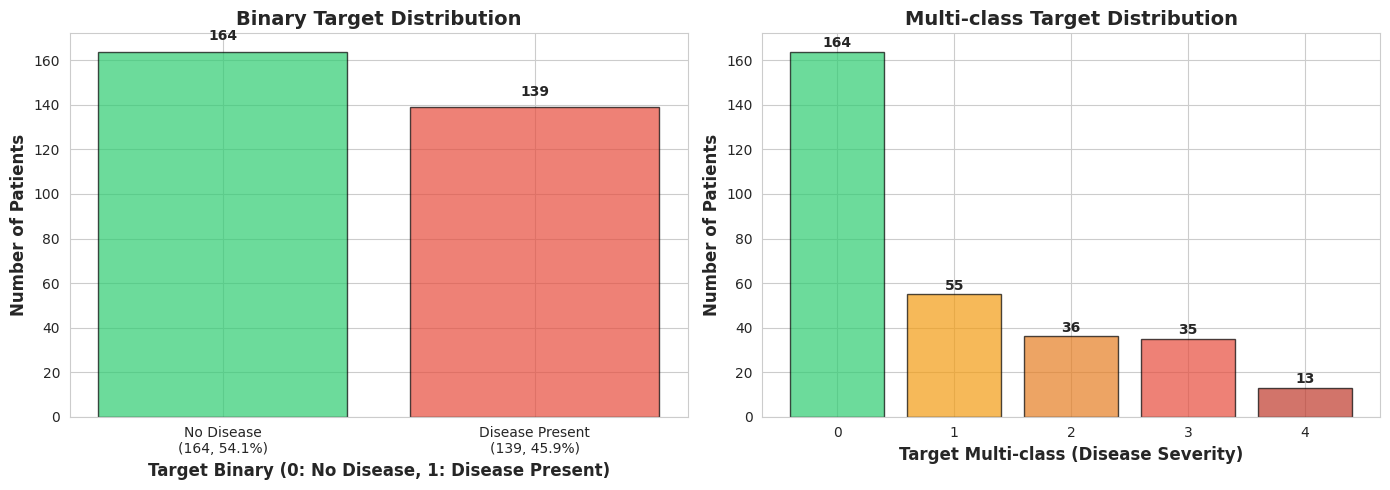

In [34]:

# ============================================================================
# 3.1.1 TARGET VARIABLE DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary target distribution
target_counts_binary = df['target_binary'].value_counts()
axes[0].bar([0, 1], target_counts_binary.values, color=['#2ecc71', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Target Binary (0: No Disease, 1: Disease Present)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
axes[0].set_title('Binary Target Distribution', fontsize=14, fontweight='bold')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No Disease\n(164, 54.1%)', 'Disease Present\n(139, 45.9%)'])
for i, v in enumerate(target_counts_binary.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Multi-class target distribution
target_counts_multi = df['target'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e67e22', '#e74c3c', '#c0392b']
axes[1].bar(target_counts_multi.index, target_counts_multi.values, color=colors, alpha=0.7, edgecolor='black')
axes[1].set_xlabel('Target Multi-class (Disease Severity)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Number of Patients', fontsize=12, fontweight='bold')
axes[1].set_title('Multi-class Target Distribution', fontsize=14, fontweight='bold')
axes[1].set_xticks([0, 1, 2, 3, 4])
for i, v in enumerate(target_counts_multi.values):
    axes[1].text(i, v + 2, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('01_target_distribution.png', dpi=300, bbox_inches='tight')
print("\n Figure 1 saved: '01_target_distribution.png'")
plt.show()


 Figure 2 saved: '02_numerical_distributions.png'


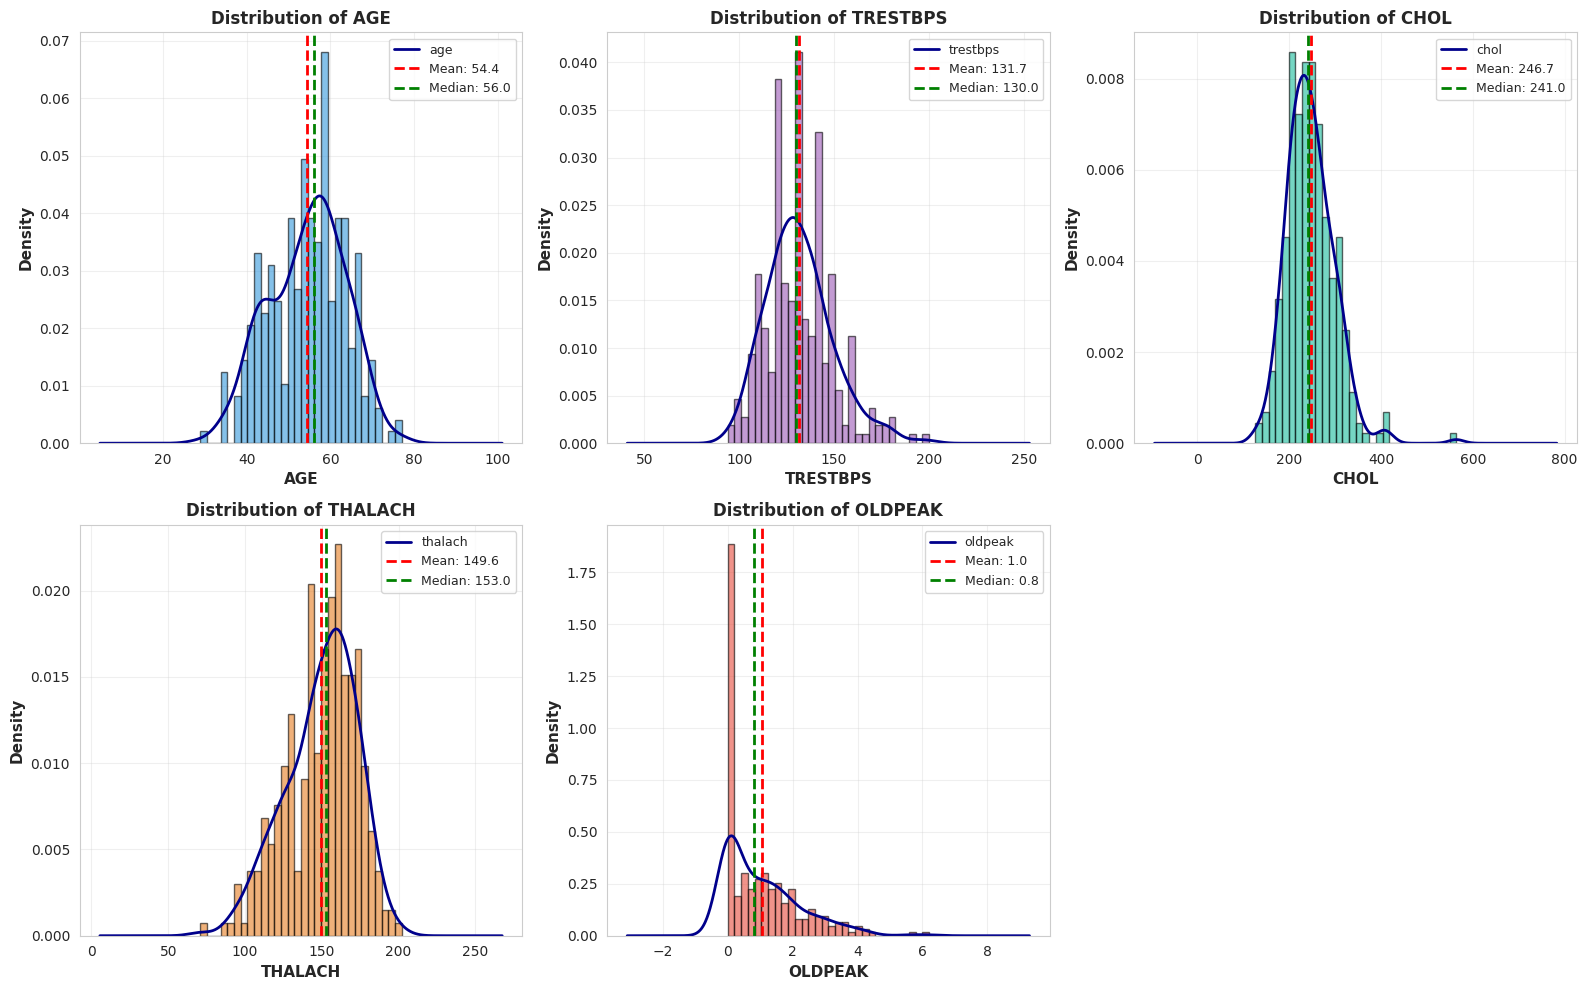

In [35]:

# ============================================================================
# 3.1.2 NUMERICAL FEATURES DISTRIBUTION
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
colors_num = ['#3498db', '#9b59b6', '#1abc9c', '#e67e22', '#e74c3c']

for idx, (col, color) in enumerate(zip(numerical_features, colors_num)):
    # Histogram with KDE
    axes[idx].hist(df[col], bins=30, color=color, alpha=0.6, edgecolor='black', density=True)
    df[col].plot(kind='kde', ax=axes[idx], color='darkblue', linewidth=2)

    axes[idx].set_xlabel(col.upper(), fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Density', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Distribution of {col.upper()}', fontsize=12, fontweight='bold')

    # Add statistics
    mean_val = df[col].mean()
    median_val = df[col].median()
    axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
    axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].grid(alpha=0.3)

# Remove extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('02_numerical_distributions.png', dpi=300, bbox_inches='tight')
print(" Figure 2 saved: '02_numerical_distributions.png'")
plt.show()


 Figure 3 saved: '03_categorical_distributions.png'


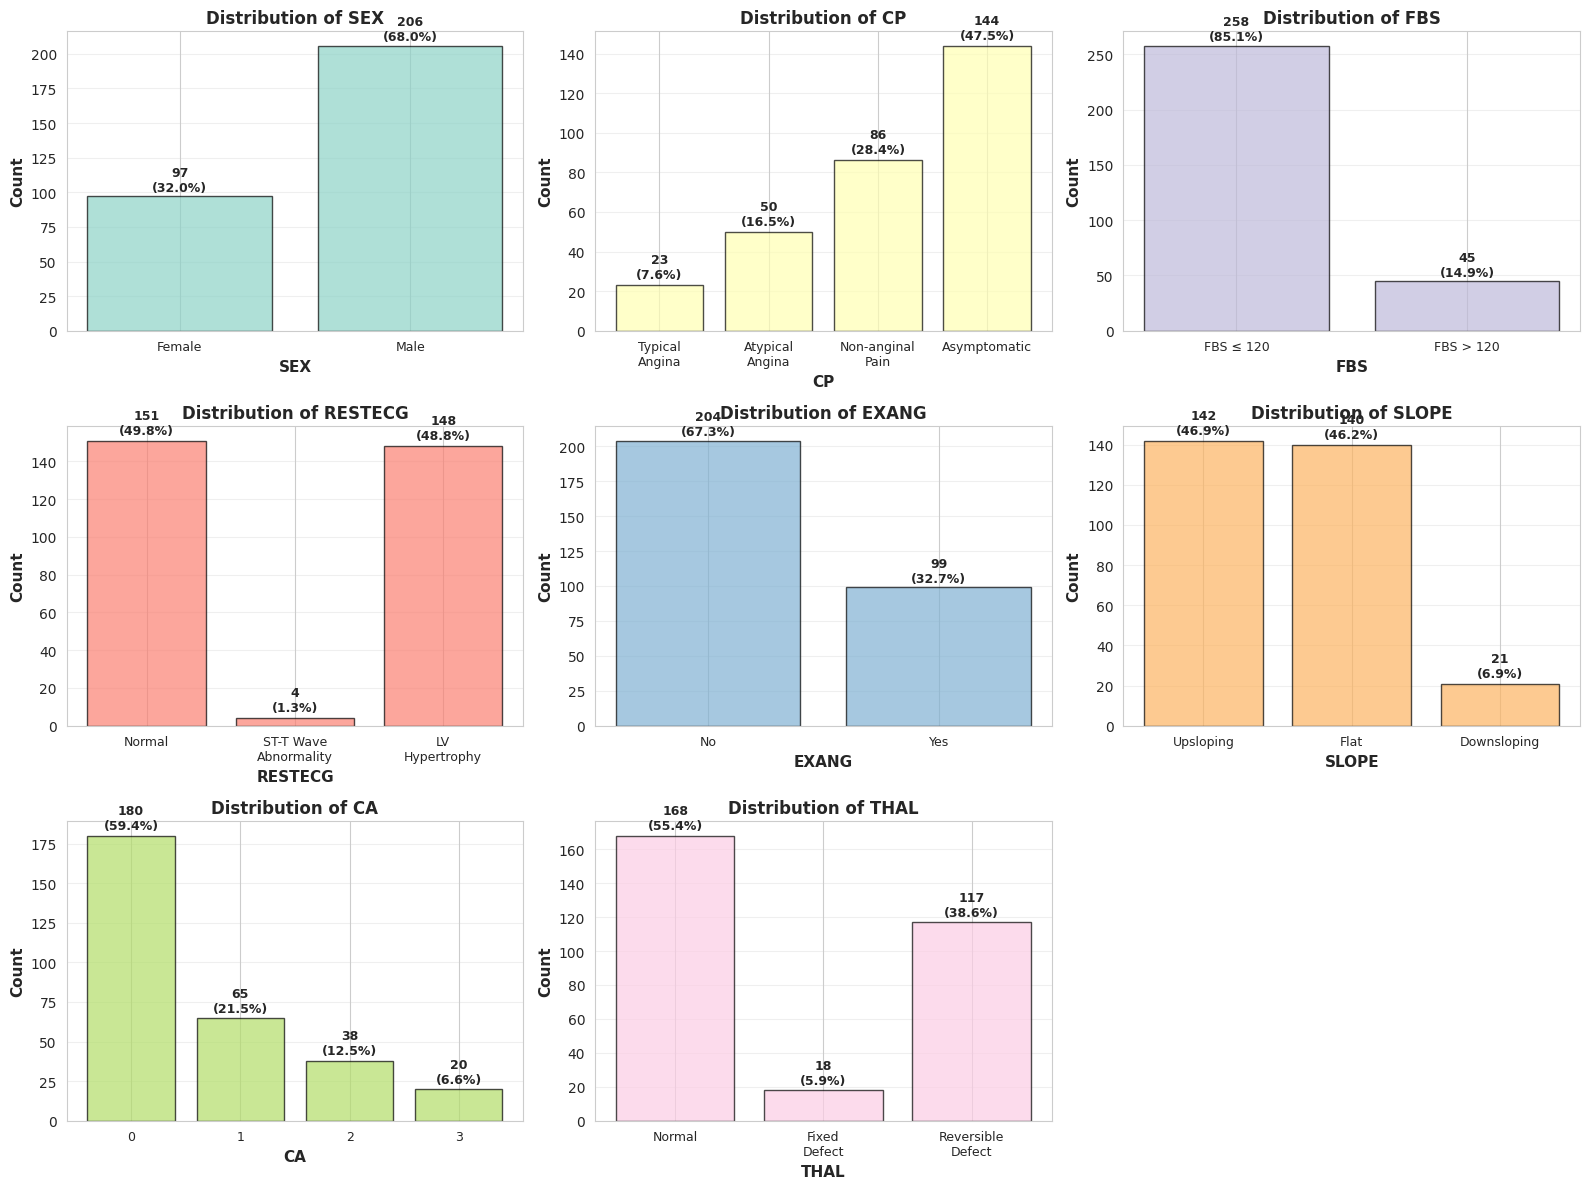

In [36]:

# ============================================================================
# 3.1.3 CATEGORICAL FEATURES DISTRIBUTION
# ============================================================================

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.ravel()

feature_labels = {
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {1: 'Typical\nAngina', 2: 'Atypical\nAngina', 3: 'Non-anginal\nPain', 4: 'Asymptomatic'},
    'fbs': {0: 'FBS ≤ 120', 1: 'FBS > 120'},
    'restecg': {0: 'Normal', 1: 'ST-T Wave\nAbnormality', 2: 'LV\nHypertrophy'},
    'exang': {0: 'No', 1: 'Yes'},
    'slope': {1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
    'ca': {0: '0', 1: '1', 2: '2', 3: '3'},
    'thal': {3: 'Normal', 6: 'Fixed\nDefect', 7: 'Reversible\nDefect'}
}

colors_cat = plt.cm.Set3(range(len(categorical_features)))

for idx, (col, color) in enumerate(zip(categorical_features, colors_cat)):
    counts = df[col].value_counts().sort_index()
    bars = axes[idx].bar(range(len(counts)), counts.values, color=color, alpha=0.7, edgecolor='black')

    axes[idx].set_xlabel(col.upper(), fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Count', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'Distribution of {col.upper()}', fontsize=12, fontweight='bold')

    # Set x-tick labels
    if col in feature_labels:
        labels = [feature_labels[col].get(int(val), str(val)) for val in counts.index]
        axes[idx].set_xticks(range(len(counts)))
        axes[idx].set_xticklabels(labels, fontsize=9)

    # Add value labels on bars
    for i, (bar, val) in enumerate(zip(bars, counts.values)):
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 2,
                      f'{val}\n({val/len(df)*100:.1f}%)',
                      ha='center', va='bottom', fontsize=9, fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='y')

# Remove extra subplot
axes[8].axis('off')

plt.tight_layout()
plt.savefig('03_categorical_distributions.png', dpi=300, bbox_inches='tight')
print(" Figure 3 saved: '03_categorical_distributions.png'")
plt.show()


In [37]:
print("\n" + "=" * 80)
print("STEP 3.1 COMPLETE - Distribution Analysis Done!")
print("=" * 80)
print("\n GENERATED FIGURES:")
print("   1. 01_target_distribution.png - Target variable distributions")
print("   2. 02_numerical_distributions.png - Numerical features distributions")
print("   3. 03_categorical_distributions.png - Categorical features distributions")




STEP 3.1 COMPLETE - Distribution Analysis Done!

 GENERATED FIGURES:
   1. 01_target_distribution.png - Target variable distributions
   2. 02_numerical_distributions.png - Numerical features distributions
   3. 03_categorical_distributions.png - Categorical features distributions


STEP 3.2: CORRELATION ANALYSIS (Heat Maps & Statistical Tests)

STEP 3.2: CORRELATION ANALYSIS

 Figure 4 saved: '04_correlation_matrix_all.png'


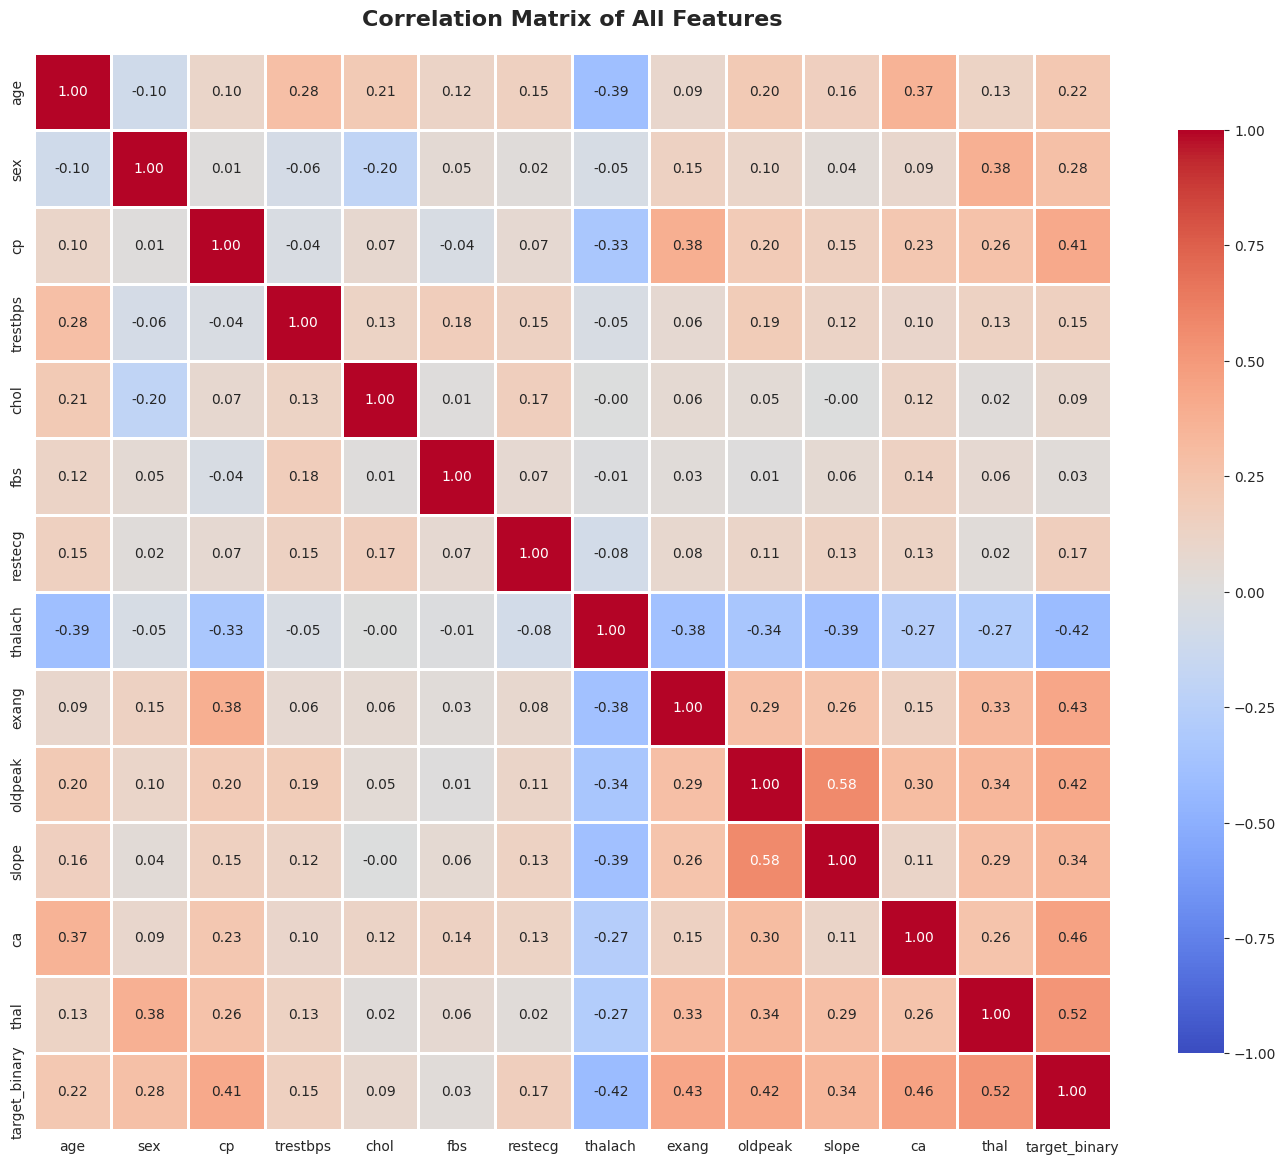

In [38]:
# ============================================================================
# STEP 3.2: CORRELATION ANALYSIS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("=" * 80)
print("STEP 3.2: CORRELATION ANALYSIS")
print("=" * 80)

# ============================================================================
# 3.2.1 CORRELATION MATRIX - ALL FEATURES
# ============================================================================

# Calculate correlation matrix
correlation_matrix = df.drop('target', axis=1).corr()

# Create figure
fig, ax = plt.subplots(figsize=(14, 12))

# Create heatmap
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Correlation Matrix of All Features', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('04_correlation_matrix_all.png', dpi=300, bbox_inches='tight')
print("\n Figure 4 saved: '04_correlation_matrix_all.png'")
plt.show()



CORRELATION WITH TARGET VARIABLE (Sorted by Strength)
target_binary    1.000000
thal             0.522057
ca               0.460033
exang            0.431894
oldpeak          0.424510
cp               0.414446
slope            0.339213
sex              0.276816
age              0.223120
restecg          0.169202
trestbps         0.150825
chol             0.085164
fbs              0.025264
thalach         -0.417167
dtype: float64
 Figure 5 saved: '05_target_correlations.png'


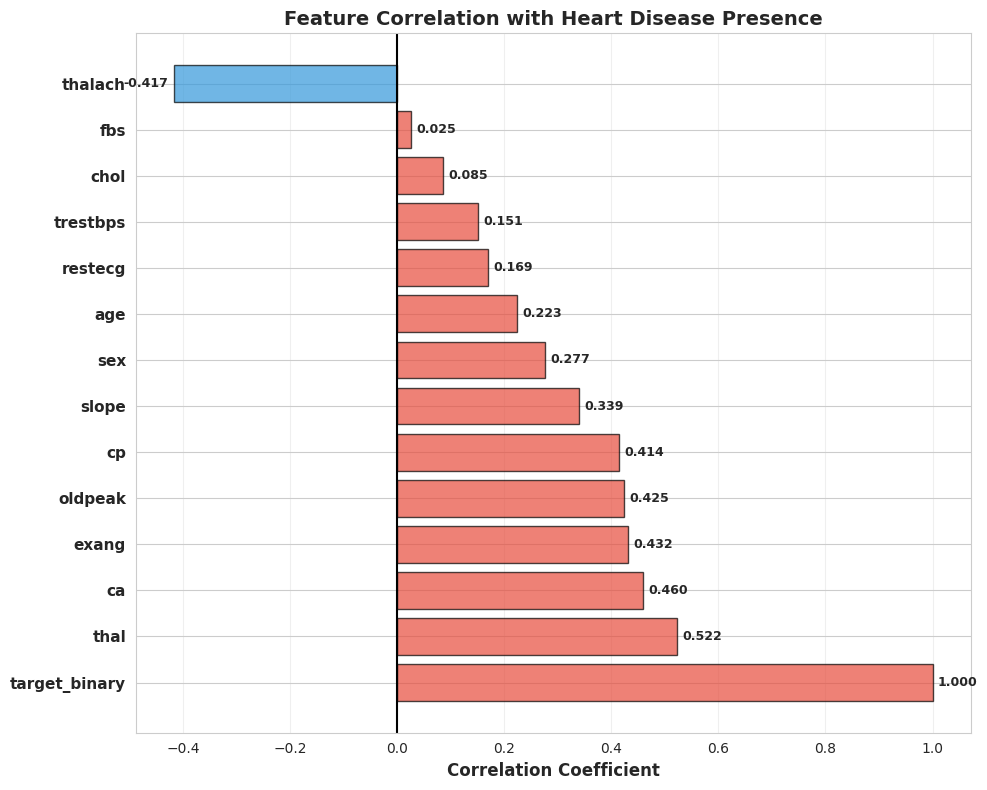

In [39]:

# ============================================================================
# 3.2.2 CORRELATION WITH TARGET VARIABLE
# ============================================================================

# Calculate correlation with target_binary
target_corr = df.drop(['target'], axis=1).corrwith(df['target_binary']).sort_values(ascending=False)

print("\n" + "=" * 80)
print("CORRELATION WITH TARGET VARIABLE (Sorted by Strength)")
print("=" * 80)
print(target_corr)

# Visualize correlations with target
fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c' if x > 0 else '#3498db' for x in target_corr.values]
bars = ax.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index, fontsize=11, fontweight='bold')
ax.set_xlabel('Correlation Coefficient', fontsize=12, fontweight='bold')
ax.set_title('Feature Correlation with Heart Disease Presence', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.5)
ax.grid(alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, target_corr.values)):
    ax.text(val + (0.01 if val > 0 else -0.01), i, f'{val:.3f}',
            va='center', ha='left' if val > 0 else 'right', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('05_target_correlations.png', dpi=300, bbox_inches='tight')
print(" Figure 5 saved: '05_target_correlations.png'")
plt.show()


In [40]:

# ============================================================================
# 3.2.3 TOP CORRELATIONS ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("TOP CORRELATIONS ANALYSIS")
print("=" * 80)

# Find top positive correlations with target
print("\n TOP 5 POSITIVE CORRELATIONS WITH DISEASE:")
top_positive = target_corr[target_corr > 0].head(5)
for feat, corr in top_positive.items():
    print(f"   {feat:12s}: {corr:+.3f} - {'Strong' if abs(corr) > 0.3 else 'Moderate' if abs(corr) > 0.2 else 'Weak'} positive correlation")

# Find top negative correlations with target
print("\n TOP 5 NEGATIVE CORRELATIONS WITH DISEASE:")
top_negative = target_corr[target_corr < 0].tail(5).sort_values()
for feat, corr in top_negative.items():
    print(f"   {feat:12s}: {corr:+.3f} - {'Strong' if abs(corr) > 0.3 else 'Moderate' if abs(corr) > 0.2 else 'Weak'} negative correlation")





TOP CORRELATIONS ANALYSIS

 TOP 5 POSITIVE CORRELATIONS WITH DISEASE:
   target_binary: +1.000 - Strong positive correlation
   thal        : +0.522 - Strong positive correlation
   ca          : +0.460 - Strong positive correlation
   exang       : +0.432 - Strong positive correlation
   oldpeak     : +0.425 - Strong positive correlation

 TOP 5 NEGATIVE CORRELATIONS WITH DISEASE:
   thalach     : -0.417 - Strong negative correlation


In [41]:
# ============================================================================
# 3.2.4 STRONG INTER-FEATURE CORRELATIONS
# ============================================================================

print("\n" + "=" * 80)
print("STRONG INTER-FEATURE CORRELATIONS (|r| > 0.4)")
print("=" * 80)

# Find strong correlations between features (excluding diagonal and duplicates)
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.4:
            strong_corr.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if strong_corr:
    strong_corr_df = pd.DataFrame(strong_corr).sort_values('Correlation', key=abs, ascending=False)
    print("\n  MULTICOLLINEARITY WARNING:")
    print(strong_corr_df.to_string(index=False))
else:
    print("\n No strong inter-feature correlations detected (|r| > 0.4)")

print("\n" + "=" * 80)
print(" STEP 3.2 COMPLETE - Correlation Analysis Done!")
print("=" * 80)


STRONG INTER-FEATURE CORRELATIONS (|r| > 0.4)

  MULTICOLLINEARITY WARNING:
Feature 1     Feature 2  Correlation
  oldpeak         slope     0.577537
     thal target_binary     0.522057
       ca target_binary     0.460033
    exang target_binary     0.431894
  oldpeak target_binary     0.424510
  thalach target_binary    -0.417167
       cp target_binary     0.414446

 STEP 3.2 COMPLETE - Correlation Analysis Done!


**week 3**

STEP 3.3: FEATURE-TARGET RELATIONSHIPS

Analyzing how each feature differs between disease/no-disease groups...
 Figure 6 saved: '06_numerical_by_target_violin.png'


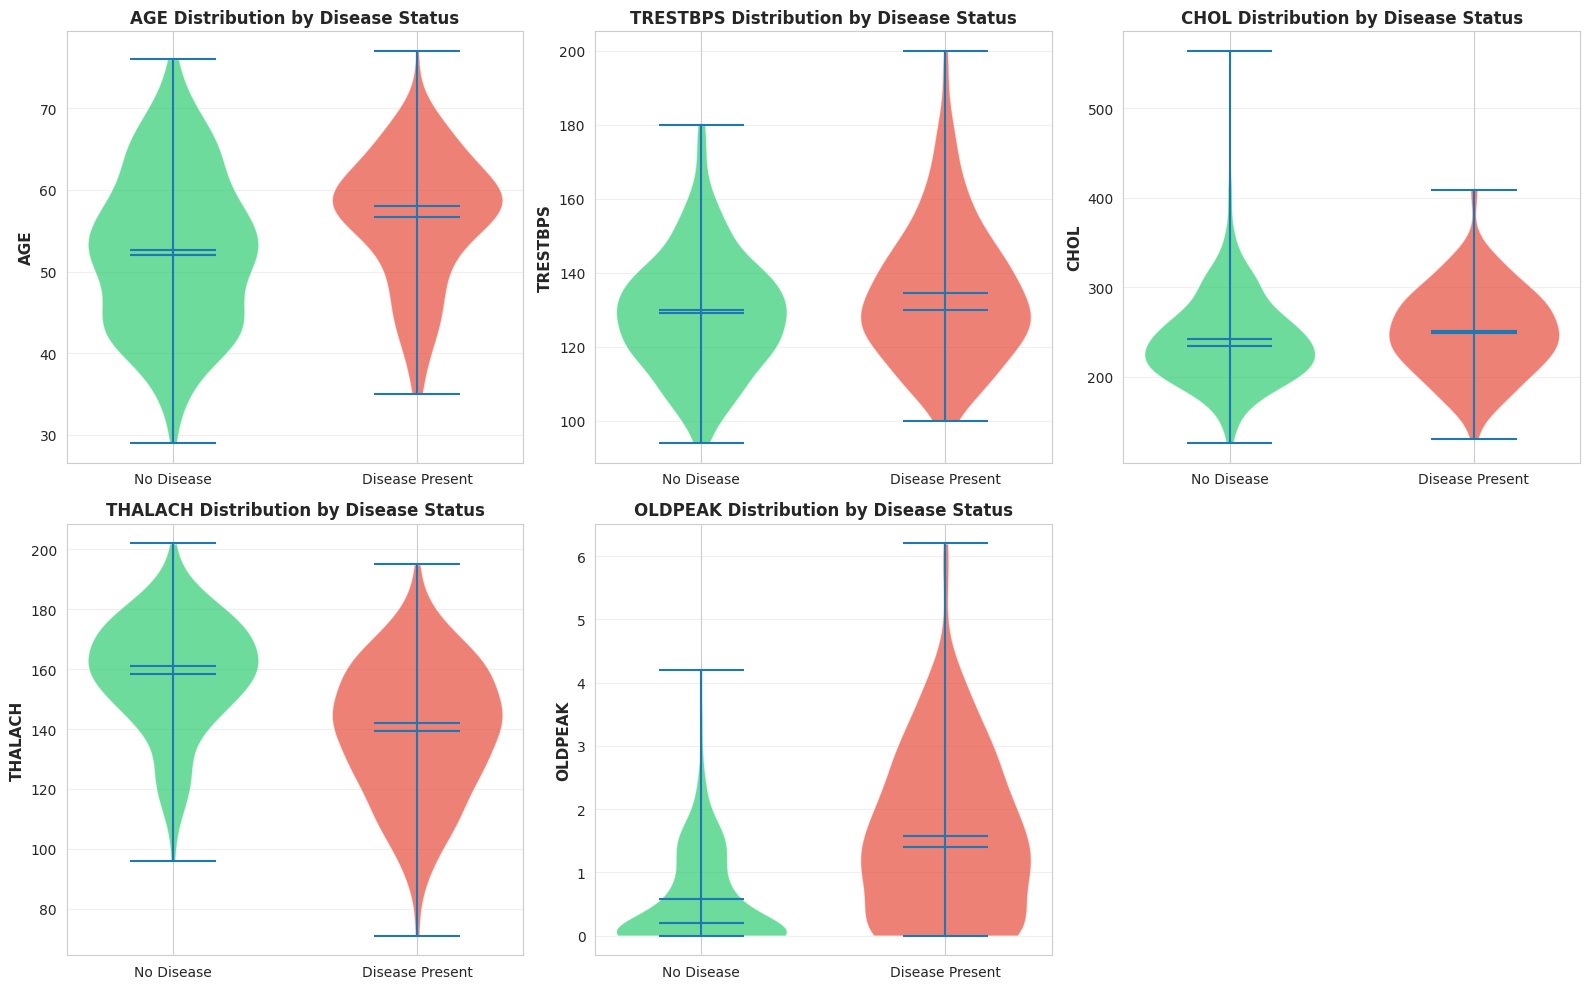

 Figure 7 saved: '07_categorical_by_target_grouped.png'


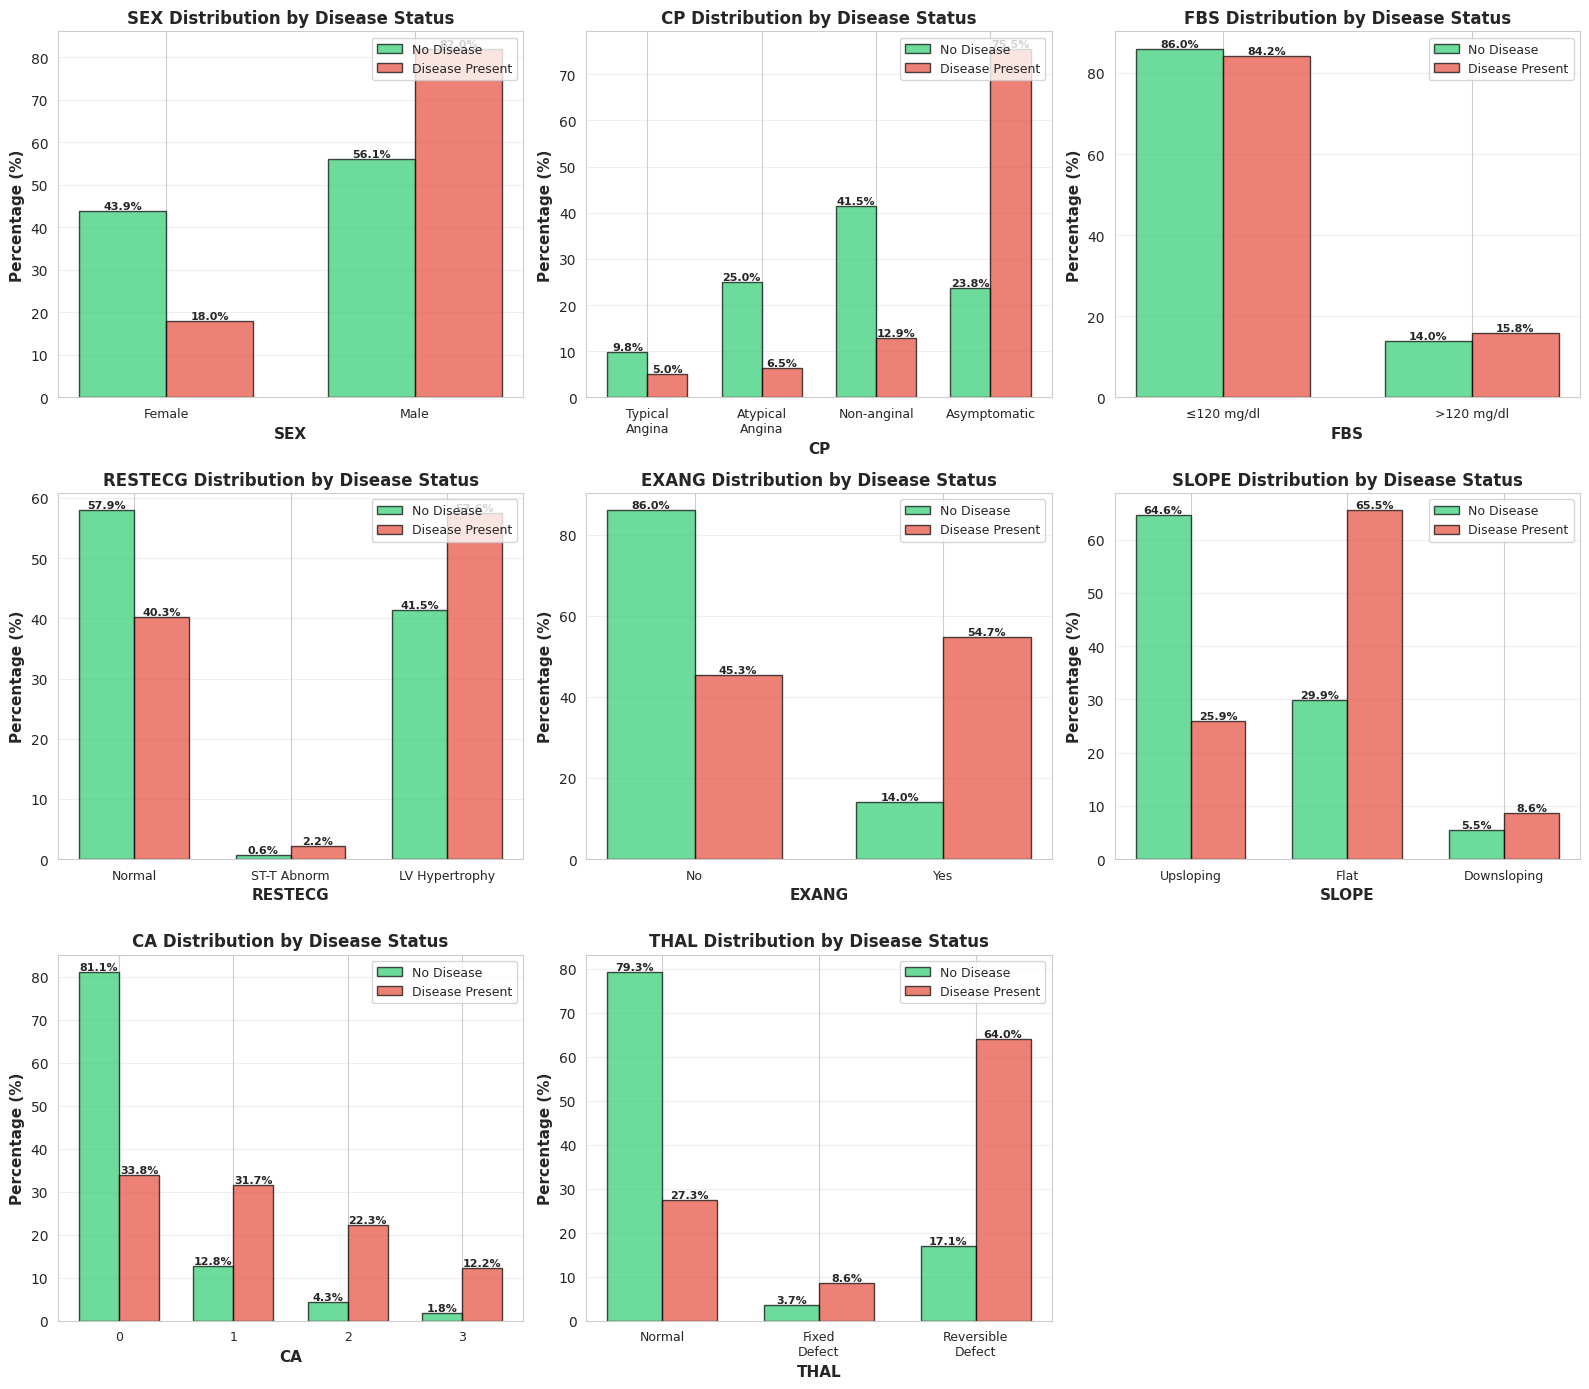


STATISTICAL SIGNIFICANCE TESTS

 NUMERICAL FEATURES - T-TEST (Two-Sample)
Testing if means differ significantly between disease groups

age         : t= -3.971, p=0.000090 ***
              No Disease: μ=52.59 (σ=9.51)
              Disease:    μ=56.63 (σ=7.94)

trestbps    : t= -2.647, p=0.008548 **
              No Disease: μ=129.25 (σ=16.20)
              Disease:    μ=134.57 (σ=18.77)

chol        : t= -1.483, p=0.139142 ns
              No Disease: μ=242.64 (σ=53.46)
              Disease:    μ=251.47 (σ=49.49)

thalach     : t= +7.964, p=0.000000 ***
              No Disease: μ=158.38 (σ=19.20)
              Disease:    μ=139.26 (σ=22.59)

oldpeak     : t= -8.134, p=0.000000 ***
              No Disease: μ=0.59 (σ=0.78)
              Disease:    μ=1.57 (σ=1.30)


 CATEGORICAL FEATURES - CHI-SQUARE TEST
Testing if distributions differ significantly between disease groups

sex         : χ²= 22.043, p=0.000003 ***
cp          : χ²= 81.816, p=0.000000 ***
fbs         : χ²=  0.077, p

In [42]:
# ============================================================================
# STEP 3.3: FEATURE-TARGET RELATIONSHIPS ANALYSIS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

print("=" * 80)
print("STEP 3.3: FEATURE-TARGET RELATIONSHIPS")
print("=" * 80)
print("\nAnalyzing how each feature differs between disease/no-disease groups...")

# ============================================================================
# 3.3.1 NUMERICAL FEATURES BY TARGET - VIOLIN PLOTS
# ============================================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()

for idx, feature in enumerate(numerical_features):
    # Violin plot
    parts = axes[idx].violinplot([df[df['target_binary']==0][feature].dropna(),
                                  df[df['target_binary']==1][feature].dropna()],
                                 positions=[1, 2],
                                 showmeans=True,
                                 showmedians=True,
                                 widths=0.7)

    # Color the violins
    colors = ['#2ecc71', '#e74c3c']
    for pc, color in zip(parts['bodies'], colors):
        pc.set_facecolor(color)
        pc.set_alpha(0.7)

    axes[idx].set_xticks([1, 2])
    axes[idx].set_xticklabels(['No Disease', 'Disease Present'])
    axes[idx].set_ylabel(feature.upper(), fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature.upper()} Distribution by Disease Status', fontsize=12, fontweight='bold')
    axes[idx].grid(alpha=0.3, axis='y')

# Remove extra subplot
axes[5].axis('off')

plt.tight_layout()
plt.savefig('06_numerical_by_target_violin.png', dpi=300, bbox_inches='tight')
print(" Figure 6 saved: '06_numerical_by_target_violin.png'")
plt.show()

# ============================================================================
# 3.3.3 CATEGORICAL FEATURES BY TARGET - GROUPED BAR CHARTS
# ============================================================================

categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.ravel()

feature_labels = {
    'sex': {0: 'Female', 1: 'Male'},
    'cp': {1: 'Typical\nAngina', 2: 'Atypical\nAngina', 3: 'Non-anginal', 4: 'Asymptomatic'},
    'fbs': {0: '≤120 mg/dl', 1: '>120 mg/dl'},
    'restecg': {0: 'Normal', 1: 'ST-T Abnorm', 2: 'LV Hypertrophy'},
    'exang': {0: 'No', 1: 'Yes'},
    'slope': {1: 'Upsloping', 2: 'Flat', 3: 'Downsloping'},
    'ca': {0: '0', 1: '1', 2: '2', 3: '3'},
    'thal': {3: 'Normal', 6: 'Fixed\nDefect', 7: 'Reversible\nDefect'}
}

for idx, feature in enumerate(categorical_features):
    # Calculate percentages for each category
    ct = pd.crosstab(df[feature], df['target_binary'], normalize='columns') * 100

    # Plot grouped bars
    x = np.arange(len(ct))
    width = 0.35

    bars1 = axes[idx].bar(x - width/2, ct[0], width, label='No Disease',
                          color='#2ecc71', alpha=0.7, edgecolor='black')
    bars2 = axes[idx].bar(x + width/2, ct[1], width, label='Disease Present',
                          color='#e74c3c', alpha=0.7, edgecolor='black')

    axes[idx].set_xlabel(feature.upper(), fontsize=11, fontweight='bold')
    axes[idx].set_ylabel('Percentage (%)', fontsize=11, fontweight='bold')
    axes[idx].set_title(f'{feature.upper()} Distribution by Disease Status', fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x)

    if feature in feature_labels:
        labels = [feature_labels[feature].get(int(val), str(val)) for val in ct.index]
        axes[idx].set_xticklabels(labels, fontsize=9)
    else:
        axes[idx].set_xticklabels(ct.index)

    axes[idx].legend(loc='upper right', fontsize=9)
    axes[idx].grid(alpha=0.3, axis='y')

    # Add value labels
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width()/2., height,
                          f'{height:.1f}%',
                          ha='center', va='bottom', fontsize=8, fontweight='bold')

# Remove extra subplot
axes[8].axis('off')

plt.tight_layout()
plt.savefig('07_categorical_by_target_grouped.png', dpi=300, bbox_inches='tight')
print(" Figure 7 saved: '07_categorical_by_target_grouped.png'")
plt.show()

# ============================================================================
# 3.3.4 STATISTICAL SIGNIFICANCE TESTS
# ============================================================================

from scipy import stats

print("\n" + "=" * 80)
print("STATISTICAL SIGNIFICANCE TESTS")
print("=" * 80)

print("\n NUMERICAL FEATURES - T-TEST (Two-Sample)")
print("Testing if means differ significantly between disease groups\n")

for feature in numerical_features:
    no_disease = df[df['target_binary']==0][feature].dropna()
    disease = df[df['target_binary']==1][feature].dropna()

    t_stat, p_value = stats.ttest_ind(no_disease, disease)

    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"

    print(f"{feature:12s}: t={t_stat:+7.3f}, p={p_value:.6f} {significance}")
    print(f"              No Disease: μ={no_disease.mean():.2f} (σ={no_disease.std():.2f})")
    print(f"              Disease:    μ={disease.mean():.2f} (σ={disease.std():.2f})")
    print()

print("\n CATEGORICAL FEATURES - CHI-SQUARE TEST")
print("Testing if distributions differ significantly between disease groups\n")

for feature in categorical_features:
    ct = pd.crosstab(df[feature], df['target_binary'])
    chi2, p_value, dof, expected = stats.chi2_contingency(ct)

    significance = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else "ns"

    print(f"{feature:12s}: χ²={chi2:7.3f}, p={p_value:.6f} {significance}")

print("\n" + "=" * 80)
print("LEGEND:")
print("  *** p < 0.001 (Highly significant)")
print("  **  p < 0.01  (Very significant)")
print("  *   p < 0.05  (Significant)")
print("  ns  p ≥ 0.05  (Not significant)")
print("=" * 80)



4: FEATURE PREPARATION & TRAIN-TEST SPLIT


In [43]:
# ============================================================================
# PHASE 4: FEATURE ENGINEERING & PREPARATION FOR MODELING
# ============================================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

print("=" * 80)
print("PHASE 4: FEATURE ENGINEERING & DATA PREPARATION")
print("=" * 80)

# ============================================================================
# 4.1: FEATURE SELECTION BASED ON EDA INSIGHTS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4.1: FEATURE SELECTION")
print("=" * 80)

# Based on our statistical analysis, we have two strategies:
# Strategy 1: Keep all features
# Strategy 2: Remove non-significant features (chol, fbs)

# Let's prepare both versions
print("\n FEATURE SELECTION STRATEGIES:")
print("\nStrategy 1: ALL FEATURES (13 features)")
print("   - Keep all features including chol and fbs")
print("   - Let the model decide feature importance")

print("\nStrategy 2: SIGNIFICANT FEATURES ONLY (11 features)")
print("   - Remove: chol (p=0.139), fbs (p=0.781)")
print("   - Keep only statistically significant features (p < 0.05)")

# For this project, we'll use Strategy 1 initially and compare
# We'll use Strategy 2 later for comparison

# Define feature sets
all_features = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

significant_features = ['age', 'sex', 'cp', 'trestbps', 'restecg',
                        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

print(f"\n All features ({len(all_features)}): {all_features}")

print(f" Significant features ({len(significant_features)}): {significant_features}")

PHASE 4: FEATURE ENGINEERING & DATA PREPARATION

STEP 4.1: FEATURE SELECTION

 FEATURE SELECTION STRATEGIES:

Strategy 1: ALL FEATURES (13 features)
   - Keep all features including chol and fbs
   - Let the model decide feature importance

Strategy 2: SIGNIFICANT FEATURES ONLY (11 features)
   - Remove: chol (p=0.139), fbs (p=0.781)
   - Keep only statistically significant features (p < 0.05)

 All features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
 Significant features (11): ['age', 'sex', 'cp', 'trestbps', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


In [44]:

# ============================================================================
# 4.2: PREPARE X AND y
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4.2: PREPARE FEATURE MATRIX (X) AND TARGET (y)")
print("=" * 80)

# Using ALL features for now
X = df[all_features].copy()
y = df['target_binary'].copy()

print(f"\n Feature matrix (X) shape: {X.shape}")
print(f" Target vector (y) shape: {y.shape}")
print(f" Target distribution:")
print(f"   - Class 0 (No Disease): {(y==0).sum()} samples ({(y==0).sum()/len(y)*100:.1f}%)")
print(f"   - Class 1 (Disease): {(y==1).sum()} samples ({(y==1).sum()/len(y)*100:.1f}%)")


STEP 4.2: PREPARE FEATURE MATRIX (X) AND TARGET (y)

 Feature matrix (X) shape: (303, 13)
 Target vector (y) shape: (303,)
 Target distribution:
   - Class 0 (No Disease): 164 samples (54.1%)
   - Class 1 (Disease): 139 samples (45.9%)


In [45]:



# ============================================================================
# 4.3: TRAIN-TEST SPLIT
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4.3: TRAIN-TEST SPLIT")
print("=" * 80)

# Split with stratification to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,  # 80-20 split
    random_state=42,  # For reproducibility
    stratify=y  # Maintain class distribution
)

print(f"\n Train-Test Split: 80-20")
print(f" Random State: 42 (for reproducibility)")
print(f" Stratified: Yes (maintains class balance)")

print(f"\n SPLIT SUMMARY:")
print(f"   Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"   Test set:     {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\n CLASS DISTRIBUTION:")
print(f"   Training set:")
print(f"      - Class 0: {(y_train==0).sum()} ({(y_train==0).sum()/len(y_train)*100:.1f}%)")
print(f"      - Class 1: {(y_train==1).sum()} ({(y_train==1).sum()/len(y_train)*100:.1f}%)")
print(f"   Test set:")
print(f"      - Class 0: {(y_test==0).sum()} ({(y_test==0).sum()/len(y_test)*100:.1f}%)")
print(f"      - Class 1: {(y_test==1).sum()} ({(y_test==1).sum()/len(y_test)*100:.1f}%)")


STEP 4.3: TRAIN-TEST SPLIT

 Train-Test Split: 80-20
 Random State: 42 (for reproducibility)
 Stratified: Yes (maintains class balance)

 SPLIT SUMMARY:
   Training set: 242 samples (79.9%)
   Test set:     61 samples (20.1%)

 CLASS DISTRIBUTION:
   Training set:
      - Class 0: 131 (54.1%)
      - Class 1: 111 (45.9%)
   Test set:
      - Class 0: 33 (54.1%)
      - Class 1: 28 (45.9%)


In [46]:


# ============================================================================
# 4.4: FEATURE SCALING
# ============================================================================

print("\n" + "=" * 80)
print("STEP 4.4: FEATURE SCALING")
print("=" * 80)


# Initialize scaler
scaler = StandardScaler()

# Fit on training data only (to prevent data leakage)
scaler.fit(X_train)

# Transform both training and test sets
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert back to DataFrame for easier handling
X_train_scaled = pd.DataFrame(X_train_scaled, columns=all_features, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=all_features, index=X_test.index)

print(f"\n Scaler fitted on training data only")
print(f" Training and test sets transformed")

print(f"\n SCALING VERIFICATION:")
print(f"   Training set (scaled):")
print(f"      - Mean: {X_train_scaled.mean().mean():.6f} (should be ≈ 0)")
print(f"      - Std:  {X_train_scaled.std().mean():.6f} (should be ≈ 1)")

print(f"\n EXAMPLE - AGE SCALING:")
print(f"   Original: min={X_train['age'].min():.1f}, max={X_train['age'].max():.1f}, "
      f"mean={X_train['age'].mean():.1f}, std={X_train['age'].std():.1f}")
print(f"   Scaled:   min={X_train_scaled['age'].min():.2f}, max={X_train_scaled['age'].max():.2f}, "
      f"mean={X_train_scaled['age'].mean():.2f}, std={X_train_scaled['age'].std():.2f}")





STEP 4.4: FEATURE SCALING

 Scaler fitted on training data only
 Training and test sets transformed

 SCALING VERIFICATION:
   Training set (scaled):
      - Mean: -0.000000 (should be ≈ 0)
      - Std:  1.002073 (should be ≈ 1)

 EXAMPLE - AGE SCALING:
   Original: min=29.0, max=77.0, mean=54.5, std=9.0
   Scaled:   min=-2.85, max=2.50, mean=-0.00, std=1.00


In [47]:
# ============================================================================
# PHASE 5-6: MODEL TRAINING & EVALUATION
# ============================================================================

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                            f1_score, roc_auc_score, confusion_matrix,
                            classification_report, roc_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import time

print("=" * 80)
print("PHASE 5-6: MODEL TRAINING & EVALUATION")
print("=" * 80)

# ============================================================================
# 5.1: INITIALIZE ALL MODELS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5.1: INITIALIZE MODELS")
print("=" * 80)

# Dictionary to store models
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Support Vector Machine': SVC(random_state=42, probability=True),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, n_estimators=100, eval_metric='logloss')
}

print(f"\n Initialized {len(models)} models:")
for name in models.keys():
    print(f"   - {name}")


PHASE 5-6: MODEL TRAINING & EVALUATION

STEP 5.1: INITIALIZE MODELS

 Initialized 6 models:
   - Logistic Regression
   - Decision Tree
   - Random Forest
   - Support Vector Machine
   - Gradient Boosting
   - XGBoost


In [48]:

# ============================================================================
# 5.2: TRAIN ALL MODELS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5.2: TRAIN ALL MODELS")
print("=" * 80)

results = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    print(f"\n Training {name}...")
    start_time = time.time()

    # Train model
    model.fit(X_train_scaled, y_train)

    # Make predictions
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)

    # Get probabilities for ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob_train = model.predict_proba(X_train_scaled)[:, 1]
        y_prob_test = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_prob_train = model.decision_function(X_train_scaled)
        y_prob_test = model.decision_function(X_test_scaled)

    # Calculate metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_precision = precision_score(y_test, y_pred_test)
    test_recall = recall_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test)
    test_roc_auc = roc_auc_score(y_test, y_prob_test)

    training_time = time.time() - start_time

    # Store results
    results[name] = {
        'Train Accuracy': train_accuracy,
        'Test Accuracy': test_accuracy,
        'Precision': test_precision,
        'Recall': test_recall,
        'F1-Score': test_f1,
        'ROC-AUC': test_roc_auc,
        'Training Time (s)': training_time
    }

    predictions[name] = y_pred_test
    probabilities[name] = y_prob_test

    print(f"   Completed in {training_time:.3f}s")
    print(f"   Train Accuracy: {train_accuracy:.4f} | Test Accuracy: {test_accuracy:.4f}")


STEP 5.2: TRAIN ALL MODELS

 Training Logistic Regression...
   Completed in 0.193s
   Train Accuracy: 0.8512 | Test Accuracy: 0.8689

 Training Decision Tree...
   Completed in 0.024s
   Train Accuracy: 1.0000 | Test Accuracy: 0.7213

 Training Random Forest...
   Completed in 0.239s
   Train Accuracy: 1.0000 | Test Accuracy: 0.8852

 Training Support Vector Machine...
   Completed in 0.032s
   Train Accuracy: 0.9050 | Test Accuracy: 0.8525

 Training Gradient Boosting...
   Completed in 0.175s
   Train Accuracy: 0.9917 | Test Accuracy: 0.8525

 Training XGBoost...
   Completed in 0.134s
   Train Accuracy: 1.0000 | Test Accuracy: 0.8525


In [49]:


# ============================================================================
# 5.3: RESULTS SUMMARY TABLE
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5.3: MODEL PERFORMANCE COMPARISON")
print("=" * 80)

# Create results DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n COMPREHENSIVE RESULTS TABLE:")
print(results_df.to_string())

# Find best model for each metric
print("\n" + "=" * 80)
print("BEST PERFORMING MODELS BY METRIC")
print("=" * 80)

metrics = ['Test Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
for metric in metrics:
    best_model = results_df[metric].idxmax()
    best_score = results_df[metric].max()
    print(f"\n best!! {metric}:")
    print(f"   Model: {best_model}")
    print(f"   Score: {best_score:.4f}")


STEP 5.3: MODEL PERFORMANCE COMPARISON

 COMPREHENSIVE RESULTS TABLE:
                        Train Accuracy  Test Accuracy  Precision  Recall  F1-Score  ROC-AUC  Training Time (s)
Logistic Regression             0.8512         0.8689     0.8125  0.9286    0.8667   0.9513             0.1930
Decision Tree                   1.0000         0.7213     0.6571  0.8214    0.7302   0.7289             0.0242
Random Forest                   1.0000         0.8852     0.8182  0.9643    0.8852   0.9513             0.2393
Support Vector Machine          0.9050         0.8525     0.8065  0.8929    0.8475   0.9437             0.0319
Gradient Boosting               0.9917         0.8525     0.7879  0.9286    0.8525   0.9459             0.1751
XGBoost                         1.0000         0.8525     0.7879  0.9286    0.8525   0.9188             0.1341

BEST PERFORMING MODELS BY METRIC

 best!! Test Accuracy:
   Model: Random Forest
   Score: 0.8852

 best!! Precision:
   Model: Random Forest
   Score:


STEP 5.4: CONFUSION MATRICES

 Figure 9 saved: '09_confusion_matrices_all_models.png'


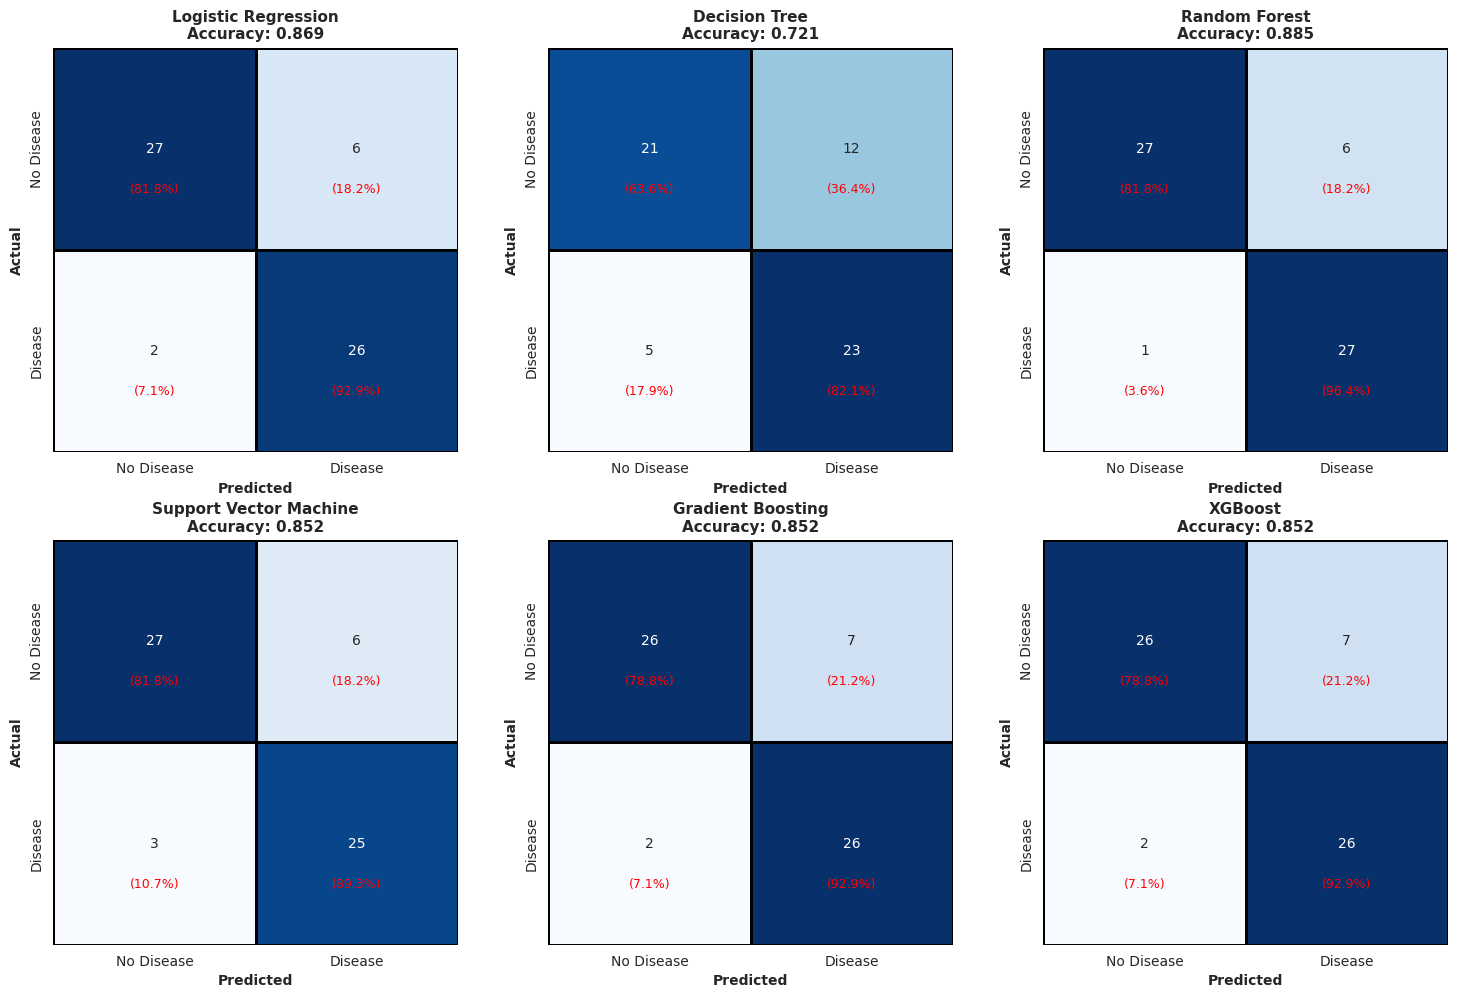

In [50]:


# ============================================================================
# 5.4: CONFUSION MATRICES FOR ALL MODELS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5.4: CONFUSION MATRICES")
print("=" * 80)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, (name, y_pred) in enumerate(predictions.items()):
    cm = confusion_matrix(y_test, y_pred)

    # Calculate percentages
    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

    # Create heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                cbar=False, square=True, linewidths=1, linecolor='black')

    # Add percentage annotations
    for i in range(2):
        for j in range(2):
            axes[idx].text(j+0.5, i+0.7, f'({cm_percent[i,j]:.1f}%)',
                          ha='center', va='center', fontsize=9, color='red')

    axes[idx].set_title(f'{name}\nAccuracy: {results[name]["Test Accuracy"]:.3f}',
                       fontsize=11, fontweight='bold')
    axes[idx].set_xlabel('Predicted', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Actual', fontsize=10, fontweight='bold')
    axes[idx].set_xticklabels(['No Disease', 'Disease'])
    axes[idx].set_yticklabels(['No Disease', 'Disease'])

plt.tight_layout()
plt.savefig('09_confusion_matrices_all_models.png', dpi=300, bbox_inches='tight')
print("\n Figure 9 saved: '09_confusion_matrices_all_models.png'")
plt.show()


STEP 5.5: ROC CURVES
 Figure 10 saved: '10_roc_curves_all_models.png'


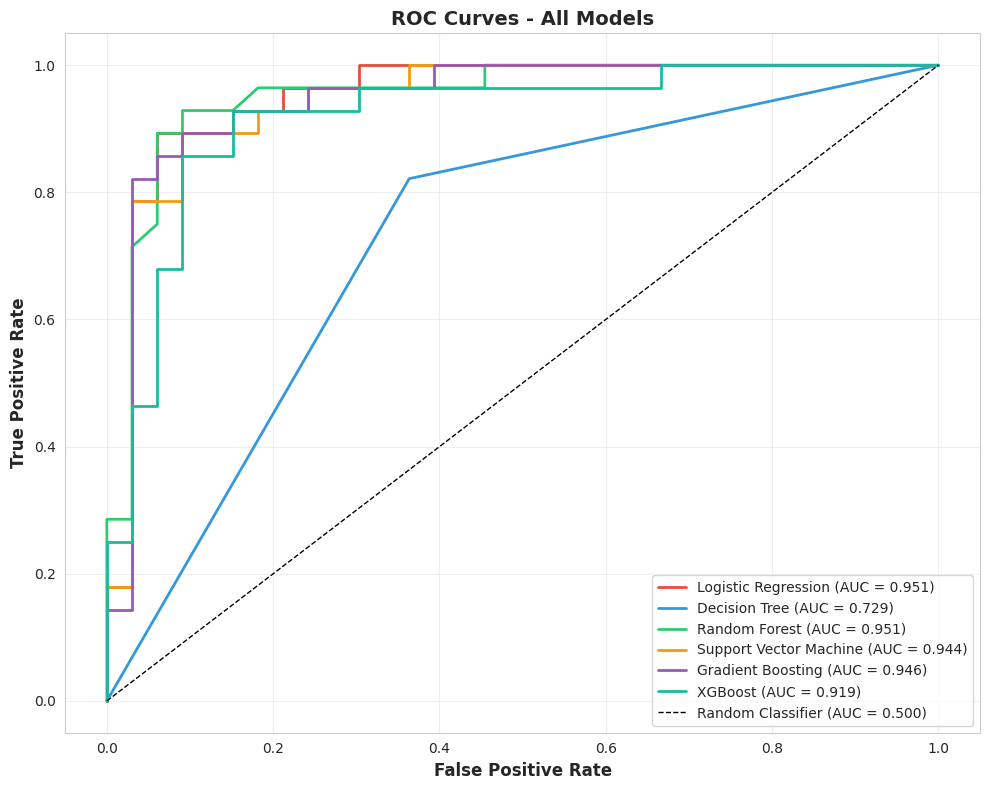

In [51]:
# ============================================================================
# 5.5: ROC CURVES FOR ALL MODELS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5.5: ROC CURVES")
print("=" * 80)

plt.figure(figsize=(10, 8))

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6', '#1abc9c']

for (name, y_prob), color in zip(probabilities.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = results[name]['ROC-AUC']

    plt.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{name} (AUC = {auc_score:.3f})')

# Plot diagonal (random classifier)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
plt.title('ROC Curves - All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('10_roc_curves_all_models.png', dpi=300, bbox_inches='tight')
print(" Figure 10 saved: '10_roc_curves_all_models.png'")
plt.show()


STEP 5.6: VISUAL MODEL COMPARISON
 Figure 11 saved: '11_model_comparison_metrics.png'


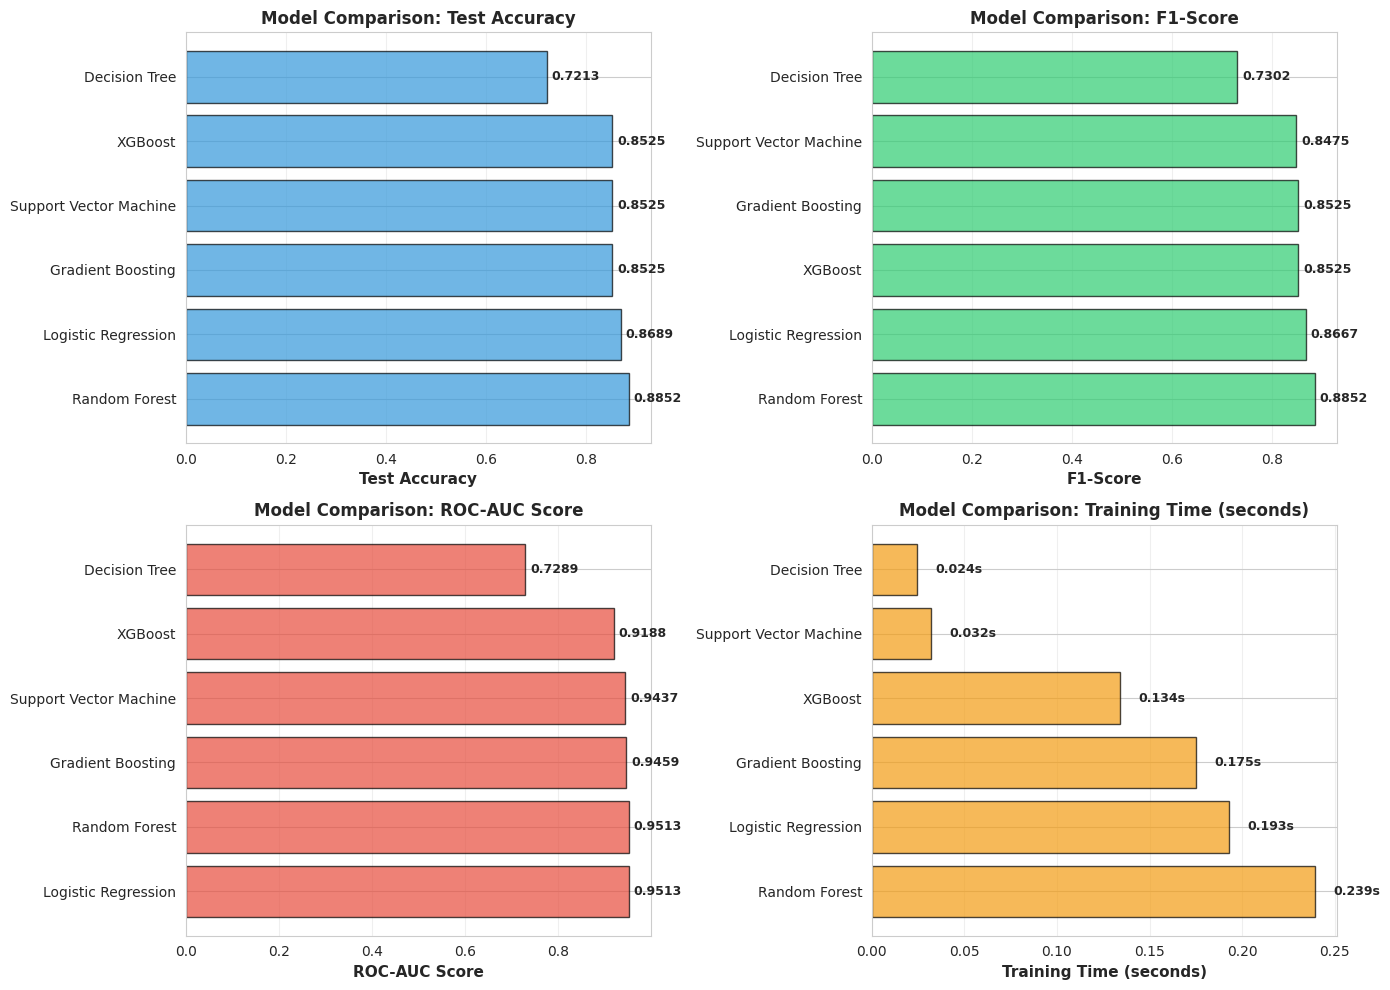

In [52]:
# ============================================================================
# 5.6: MODEL COMPARISON BAR CHARTS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5.6: VISUAL MODEL COMPARISON")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('Test Accuracy', 'Test Accuracy', '#3498db'),
    ('F1-Score', 'F1-Score', '#2ecc71'),
    ('ROC-AUC', 'ROC-AUC Score', '#e74c3c'),
    ('Training Time (s)', 'Training Time (seconds)', '#f39c12')
]

for idx, (metric, title, color) in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]

    values = results_df[metric].sort_values(ascending=False)
    bars = ax.barh(range(len(values)), values.values, color=color, alpha=0.7, edgecolor='black')

    ax.set_yticks(range(len(values)))
    ax.set_yticklabels(values.index, fontsize=10)
    ax.set_xlabel(title, fontsize=11, fontweight='bold')
    ax.set_title(f'Model Comparison: {title}', fontsize=12, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')

    # Add value labels
    for i, (bar, val) in enumerate(zip(bars, values.values)):
        ax.text(val + 0.01, i, f'{val:.4f}' if metric != 'Training Time (s)' else f'{val:.3f}s',
                va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('11_model_comparison_metrics.png', dpi=300, bbox_inches='tight')
print(" Figure 11 saved: '11_model_comparison_metrics.png'")
plt.show()

In [53]:

# ============================================================================
# 5.7: DETAILED CLASSIFICATION REPORTS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 5.7: DETAILED CLASSIFICATION REPORTS")
print("=" * 80)

for name, y_pred in predictions.items():
    print(f"\n{'='*60}")
    print(f" {name}")
    print(f"{'='*60}")
    print(classification_report(y_test, y_pred,
                                target_names=['No Disease', 'Disease Present'],
                                digits=4))




STEP 5.7: DETAILED CLASSIFICATION REPORTS

 Logistic Regression
                 precision    recall  f1-score   support

     No Disease     0.9310    0.8182    0.8710        33
Disease Present     0.8125    0.9286    0.8667        28

       accuracy                         0.8689        61
      macro avg     0.8718    0.8734    0.8688        61
   weighted avg     0.8766    0.8689    0.8690        61


 Decision Tree
                 precision    recall  f1-score   support

     No Disease     0.8077    0.6364    0.7119        33
Disease Present     0.6571    0.8214    0.7302        28

       accuracy                         0.7213        61
      macro avg     0.7324    0.7289    0.7210        61
   weighted avg     0.7386    0.7213    0.7203        61


 Random Forest
                 precision    recall  f1-score   support

     No Disease     0.9643    0.8182    0.8852        33
Disease Present     0.8182    0.9643    0.8852        28

       accuracy                         

 KEY FINDINGS FROM YOUR RESULTS:
TOP PERFORMER: RANDOM FOREST
Test Accuracy: 88.52% (54/61 correct) HIGHEST

Recall: 96.43%  BEST - Only missed 1 disease case!

F1-Score: 0.8852  BEST

ROC-AUC: 0.9513  TIED BEST with Logistic Regression

 EXCELLENT PERFORMERS (85.25% accuracy):
Logistic Regression, SVM, Gradient Boosting, XGBoost

All achieved ROC-AUC > 0.91 (excellent discrimination)

OVERFITTING DETECTION:
Decision Tree: Train=100%, Test=72% → SEVERE OVERFITTING

Random Forest: Train=100%, Test=88.5% → Slight overfitting (expected, acceptable)

XGBoost: Train=100%, Test=85.25% → Moderate overfitting

Gradient Boosting: Train=99.17%, Test=85.25% → Well-controlled

Logistic Regression: Train=85.12%, Test=86.89% → NO OVERFITTING

SVM: Train=90.5%, Test=85.25% → BEST GENERALIZATION

In [54]:
# ============================================================================
# SECTION 6: FEATURE IMPORTANCE ANALYSIS
# ============================================================================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("=" * 80)
print("SECTION 6: FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

# ============================================================================
# 6.1: EXTRACT FEATURE IMPORTANCE FROM TREE-BASED MODELS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6.1: FEATURE IMPORTANCE FROM TREE-BASED MODELS")
print("=" * 80)

# Get feature names
feature_names = all_features

# Extract importance from each model
importance_dict = {}

# Random Forest
rf_importance = models['Random Forest'].feature_importances_
importance_dict['Random Forest'] = rf_importance

# Gradient Boosting
gb_importance = models['Gradient Boosting'].feature_importances_
importance_dict['Gradient Boosting'] = gb_importance

# XGBoost
xgb_importance = models['XGBoost'].feature_importances_
importance_dict['XGBoost'] = xgb_importance

# Create DataFrame for comparison
importance_df = pd.DataFrame(importance_dict, index=feature_names)
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print("\n FEATURE IMPORTANCE RANKINGS (Tree-Based Models):")
print("\n" + importance_df.to_string())

print("\n" + "=" * 80)
print("TOP 5 MOST IMPORTANT FEATURES (by average):")
print("=" * 80)
for i, (feature, row) in enumerate(importance_df.head(5).iterrows(), 1):
    print(f"{i}. {feature:12s}: {row['Average']:.4f} (RF={row['Random Forest']:.4f}, "
          f"GB={row['Gradient Boosting']:.4f}, XGB={row['XGBoost']:.4f})")



SECTION 6: FEATURE IMPORTANCE ANALYSIS

STEP 6.1: FEATURE IMPORTANCE FROM TREE-BASED MODELS

 FEATURE IMPORTANCE RANKINGS (Tree-Based Models):

          Random Forest  Gradient Boosting   XGBoost   Average
thal           0.122940           0.270791  0.382532  0.258754
cp             0.127163           0.153881  0.112337  0.131127
ca             0.100811           0.126383  0.127586  0.118260
thalach        0.135404           0.071247  0.034865  0.080505
age            0.091327           0.094930  0.045063  0.077106
oldpeak        0.089358           0.080467  0.044870  0.071565
chol           0.088681           0.076393  0.031997  0.065690
trestbps       0.080716           0.038648  0.034086  0.051150
sex            0.035947           0.032754  0.055791  0.041497
slope          0.046626           0.026979  0.039461  0.037689
exang          0.050730           0.015323  0.037663  0.034572
restecg        0.018389           0.010953  0.031103  0.020148
fbs            0.011908           0.0

In [55]:
# ============================================================================
# 6.2: LOGISTIC REGRESSION COEFFICIENTS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6.2: LOGISTIC REGRESSION COEFFICIENTS")
print("=" * 80)

# Get coefficients (these are for scaled features)
lr_coef = models['Logistic Regression'].coef_[0]

# Create DataFrame
lr_coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_coef,
    'Abs_Coefficient': np.abs(lr_coef)
}).sort_values('Abs_Coefficient', ascending=False)

print("\n LOGISTIC REGRESSION COEFFICIENTS:")
print("(Positive = increases disease probability, Negative = decreases disease probability)")
print("\n" + lr_coef_df.to_string(index=False))

print("\n" + "=" * 80)
print("TOP 5 MOST INFLUENTIAL FEATURES (Logistic Regression):")
print("=" * 80)
for i, row in enumerate(lr_coef_df.head(5).itertuples(), 1):
    direction = "increases" if row.Coefficient > 0 else "decreases"
    print(f"{i}. {row.Feature:12s}: {row.Coefficient:+.4f} ({direction} disease probability)")




STEP 6.2: LOGISTIC REGRESSION COEFFICIENTS

 LOGISTIC REGRESSION COEFFICIENTS:
(Positive = increases disease probability, Negative = decreases disease probability)

 Feature  Coefficient  Abs_Coefficient
      ca     1.107898         1.107898
    thal     0.677821         0.677821
     sex     0.655563         0.655563
      cp     0.543483         0.543483
   exang     0.383642         0.383642
   slope     0.354072         0.354072
 thalach    -0.348486         0.348486
trestbps     0.313655         0.313655
     fbs    -0.220560         0.220560
 restecg     0.217329         0.217329
    chol     0.215375         0.215375
 oldpeak     0.149953         0.149953
     age    -0.103159         0.103159

TOP 5 MOST INFLUENTIAL FEATURES (Logistic Regression):
1. ca          : +1.1079 (increases disease probability)
2. thal        : +0.6778 (increases disease probability)
3. sex         : +0.6556 (increases disease probability)
4. cp          : +0.5435 (increases disease probability)
5. e


STEP 6.3: VISUALIZING FEATURE IMPORTANCE

 Figure 12 saved: '12_feature_importance_tree_models.png'


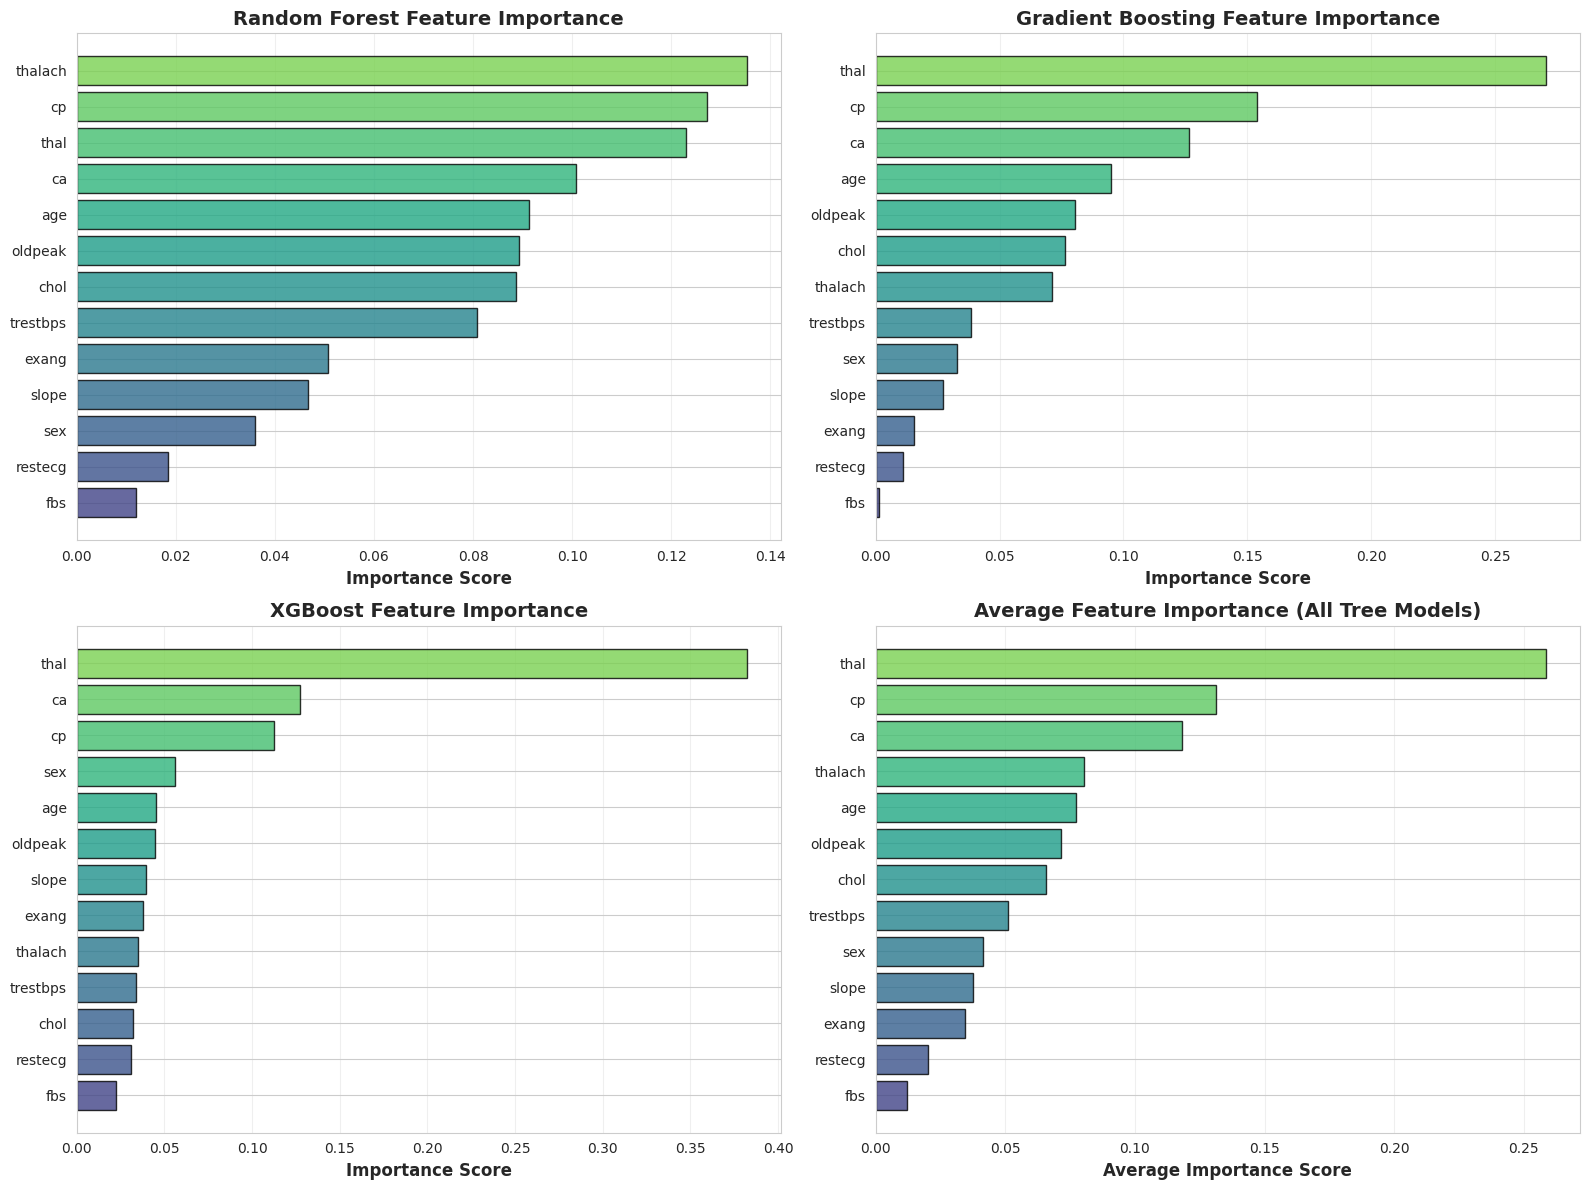

In [56]:
# ============================================================================
# 6.3: VISUALIZE FEATURE IMPORTANCE - TREE-BASED MODELS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6.3: VISUALIZING FEATURE IMPORTANCE")
print("=" * 80)

# Create figure with 4 subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Color palette
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(feature_names)))

# Plot 1: Random Forest
importance_rf_sorted = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importance
}).sort_values('Importance', ascending=True)

axes[0, 0].barh(importance_rf_sorted['Feature'], importance_rf_sorted['Importance'],
                color=colors, edgecolor='black', alpha=0.8)
axes[0, 0].set_xlabel('Importance Score', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
axes[0, 0].grid(alpha=0.3, axis='x')

# Plot 2: Gradient Boosting
importance_gb_sorted = pd.DataFrame({
    'Feature': feature_names,
    'Importance': gb_importance
}).sort_values('Importance', ascending=True)

axes[0, 1].barh(importance_gb_sorted['Feature'], importance_gb_sorted['Importance'],
                color=colors, edgecolor='black', alpha=0.8)
axes[0, 1].set_xlabel('Importance Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Gradient Boosting Feature Importance', fontsize=14, fontweight='bold')
axes[0, 1].grid(alpha=0.3, axis='x')

# Plot 3: XGBoost
importance_xgb_sorted = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_importance
}).sort_values('Importance', ascending=True)

axes[1, 0].barh(importance_xgb_sorted['Feature'], importance_xgb_sorted['Importance'],
                color=colors, edgecolor='black', alpha=0.8)
axes[1, 0].set_xlabel('Importance Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
axes[1, 0].grid(alpha=0.3, axis='x')

# Plot 4: Average Importance
importance_avg_sorted = importance_df.sort_values('Average', ascending=True)
axes[1, 1].barh(importance_avg_sorted.index, importance_avg_sorted['Average'],
                color=colors, edgecolor='black', alpha=0.8)
axes[1, 1].set_xlabel('Average Importance Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Average Feature Importance (All Tree Models)', fontsize=14, fontweight='bold')
axes[1, 1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('12_feature_importance_tree_models.png', dpi=300, bbox_inches='tight')
print("\n Figure 12 saved: '12_feature_importance_tree_models.png'")
plt.show()




 Figure 13 saved: '13_logistic_regression_coefficients.png'


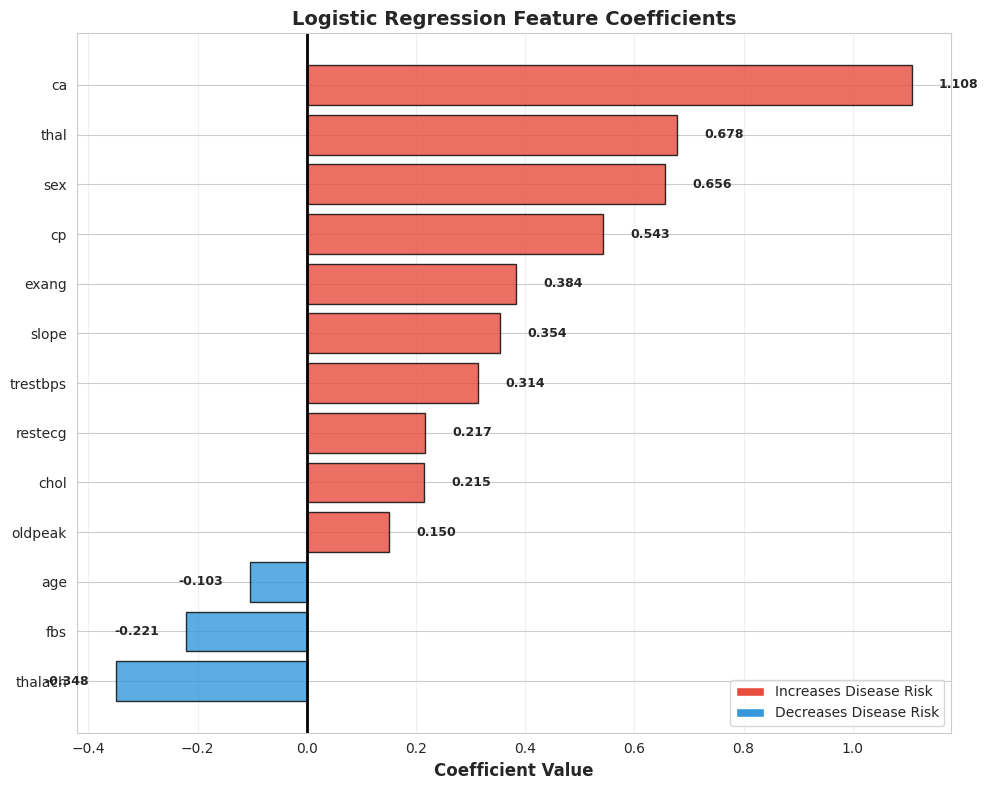

In [57]:
# ============================================================================
# 6.4: VISUALIZE LOGISTIC REGRESSION COEFFICIENTS
# ============================================================================

# Sort by absolute coefficient value
lr_coef_sorted = lr_coef_df.sort_values('Coefficient', ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

# Color code: red for positive (increases disease), blue for negative (decreases disease)
colors_lr = ['#e74c3c' if x > 0 else '#3498db' for x in lr_coef_sorted['Coefficient']]

bars = ax.barh(lr_coef_sorted['Feature'], lr_coef_sorted['Coefficient'],
               color=colors_lr, edgecolor='black', alpha=0.8)

ax.set_xlabel('Coefficient Value', fontsize=12, fontweight='bold')
ax.set_title('Logistic Regression Feature Coefficients', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
ax.grid(alpha=0.3, axis='x')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#e74c3c', label='Increases Disease Risk'),
                   Patch(facecolor='#3498db', label='Decreases Disease Risk')]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, lr_coef_sorted['Coefficient'])):
    ax.text(val + (0.05 if val > 0 else -0.05), i, f'{val:.3f}',
            va='center', ha='left' if val > 0 else 'right',
            fontweight='bold', fontsize=9)

plt.tight_layout()
plt.savefig('13_logistic_regression_coefficients.png', dpi=300, bbox_inches='tight')
print(" Figure 13 saved: '13_logistic_regression_coefficients.png'")
plt.show()



In [58]:
# ============================================================================
# 6.5: COMPARISON OF FEATURE RANKINGS ACROSS MODELS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6.5: FEATURE RANKING COMPARISON ACROSS MODELS")
print("=" * 80)

# Create ranking comparison
ranking_comparison = pd.DataFrame({
    'Feature': feature_names,
    'RF_Rank': importance_df['Random Forest'].rank(ascending=False),
    'GB_Rank': importance_df['Gradient Boosting'].rank(ascending=False),
    'XGB_Rank': importance_df['XGBoost'].rank(ascending=False),
    'LR_Rank': lr_coef_df.set_index('Feature').loc[feature_names, 'Abs_Coefficient'].rank(ascending=False)
})

ranking_comparison['Avg_Rank'] = ranking_comparison[['RF_Rank', 'GB_Rank', 'XGB_Rank', 'LR_Rank']].mean(axis=1)
ranking_comparison = ranking_comparison.sort_values('Avg_Rank')

print("\n FEATURE RANKING CONSENSUS (1=Most Important):")
print("\n" + ranking_comparison.to_string(index=False))




STEP 6.5: FEATURE RANKING COMPARISON ACROSS MODELS

 FEATURE RANKING CONSENSUS (1=Most Important):

 Feature  RF_Rank  GB_Rank  XGB_Rank  LR_Rank  Avg_Rank
   slope      3.0      1.0       1.0      2.0      1.75
     sex      4.0      3.0       2.0      1.0      2.50
trestbps      2.0      2.0       3.0      4.0      2.75
      ca      1.0      7.0       9.0      7.0      6.00
     age      5.0      4.0       5.0     13.0      6.75
   exang     11.0      9.0       4.0      3.0      6.75
 restecg      6.0      5.0       6.0     12.0      7.25
    chol      9.0     11.0       8.0      5.0      8.25
 oldpeak     10.0     10.0       7.0      6.0      8.25
    thal      8.0      8.0      10.0      8.0      8.50
      cp      7.0      6.0      11.0     11.0      8.75
 thalach     12.0     12.0      12.0     10.0     11.50
     fbs     13.0     13.0      13.0      9.0     12.00


In [59]:
# ============================================================================
# 6.6: CORRELATION WITH EDA FINDINGS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 6.6: COMPARISON WITH EDA CORRELATION ANALYSIS")
print("=" * 80)

# Get correlation with target from earlier (you did this in EDA)
# Recreate it here for comparison
target_corr = df[all_features].corrwith(df['target_binary']).abs().sort_values(ascending=False)

# Compare top features
comparison_eda = pd.DataFrame({
    'Feature': feature_names,
    'Correlation_with_Target': [abs(target_corr[f]) for f in feature_names],
    'Tree_Avg_Importance': importance_df['Average'].values,
    'LR_Abs_Coefficient': lr_coef_df.set_index('Feature').loc[feature_names, 'Abs_Coefficient'].values
})

comparison_eda = comparison_eda.sort_values('Correlation_with_Target', ascending=False)

print("\n FEATURE IMPORTANCE: EDA vs MODEL-BASED:")
print("\n" + comparison_eda.to_string(index=False))

print("\n" + "=" * 80)
print("KEY INSIGHTS:")
print("=" * 80)

# Find top 5 by each method
top_corr = set(comparison_eda.nlargest(5, 'Correlation_with_Target')['Feature'])
top_tree = set(importance_df.nlargest(5, 'Average').index)
top_lr = set(lr_coef_df.nlargest(5, 'Abs_Coefficient')['Feature'])

print(f"\n TOP 5 by EDA Correlation: {', '.join(top_corr)}")
print(f" TOP 5 by Tree Importance:  {', '.join(top_tree)}")
print(f" TOP 5 by LR Coefficients:  {', '.join(top_lr)}")

# Find consensus features (appear in all top 5)
consensus = top_corr & top_tree & top_lr
if consensus:
    print(f"\n CONSENSUS TOP FEATURES (all methods agree): {', '.join(consensus)}")
else:
    print("\n  No complete consensus across all methods")

print("\n" + "=" * 80)
print(" SECTION 6 COMPLETE - Feature Importance Analysis Done!")
print("=" * 80)
print("\n GENERATED FIGURES:")
print("   12. 12_feature_importance_tree_models.png - Tree-based model importance")
print("   13. 13_logistic_regression_coefficients.png - Logistic Regression coefficients")


STEP 6.6: COMPARISON WITH EDA CORRELATION ANALYSIS

 FEATURE IMPORTANCE: EDA vs MODEL-BASED:

 Feature  Correlation_with_Target  Tree_Avg_Importance  LR_Abs_Coefficient
    thal                 0.522057             0.011935            0.677821
      ca                 0.460033             0.020148            1.107898
   exang                 0.431894             0.041497            0.383642
 oldpeak                 0.424510             0.037689            0.149953
 thalach                 0.417167             0.051150            0.348486
      cp                 0.414446             0.118260            0.543483
   slope                 0.339213             0.034572            0.354072
     sex                 0.276816             0.131127            0.655563
     age                 0.223120             0.258754            0.103159
 restecg                 0.169202             0.065690            0.217329
trestbps                 0.150825             0.080505            0.313655
    c

PHASE 7: HYPERPARAMETER TUNING

In [60]:
# ============================================================================
# PHASE 7: HYPERPARAMETER TUNING & MODEL OPTIMIZATION
# ============================================================================

from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import make_scorer, f1_score, roc_auc_score
import pandas as pd
import numpy as np
import time

print("=" * 80)
print("PHASE 7: HYPERPARAMETER TUNING & OPTIMIZATION")
print("=" * 80)

print("""
 OBJECTIVE: Optimize hyperparameters for top-performing models to maximize performance

 MODELS TO TUNE:
   1. Random Forest (Best overall: 88.52% accuracy)
   2. Logistic Regression (Best generalization: 86.89% accuracy)
   3. XGBoost (Strong performance: 85.25% accuracy)

 METHOD: GridSearchCV with 5-fold stratified cross-validation
 OPTIMIZATION METRIC: ROC-AUC (balances sensitivity and specificity)
""")



PHASE 7: HYPERPARAMETER TUNING & OPTIMIZATION

 OBJECTIVE: Optimize hyperparameters for top-performing models to maximize performance

 MODELS TO TUNE:
   1. Random Forest (Best overall: 88.52% accuracy)
   2. Logistic Regression (Best generalization: 86.89% accuracy)
   3. XGBoost (Strong performance: 85.25% accuracy)

 METHOD: GridSearchCV with 5-fold stratified cross-validation
 OPTIMIZATION METRIC: ROC-AUC (balances sensitivity and specificity)



In [61]:
# ============================================================================
# 7.1: RANDOM FOREST HYPERPARAMETER TUNING
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7.1: TUNING RANDOM FOREST")
print("=" * 80)

print("\n HYPERPARAMETERS TO TUNE:")
print("   - n_estimators: Number of trees in forest")
print("   - max_depth: Maximum depth of each tree")
print("   - min_samples_split: Minimum samples to split node")
print("   - min_samples_leaf: Minimum samples in leaf node")

# Define parameter grid for Random Forest
rf_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print(f"\n PARAMETER GRID:")
for param, values in rf_param_grid.items():
    print(f"   {param}: {values}")

total_combinations = np.prod([len(v) for v in rf_param_grid.values()])
print(f"\n Total combinations to test: {total_combinations}")
print(f"   With 5-fold CV: {total_combinations * 5} model fits")

# Initialize GridSearchCV
from sklearn.ensemble import RandomForestClassifier

print("\n Running GridSearchCV... (this may take 1-2 minutes)")
start_time = time.time()

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=5,  # 5-fold cross-validation
    scoring='roc_auc',  # Optimize for ROC-AUC
    n_jobs=-1,  # Use all CPU cores
    verbose=1
)

# Fit on training data
rf_grid.fit(X_train_scaled, y_train)

tuning_time = time.time() - start_time

print(f"\n Tuning completed in {tuning_time:.2f} seconds")

print("\n" + "=" * 80)
print("RANDOM FOREST TUNING RESULTS")
print("=" * 80)

print(f"\n BEST PARAMETERS:")
for param, value in rf_grid.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n PERFORMANCE:")
print(f"   Best CV ROC-AUC (training): {rf_grid.best_score_:.4f}")
print(f"   Default RF ROC-AUC (training): {cross_val_score(RandomForestClassifier(random_state=42), X_train_scaled, y_train, cv=5, scoring='roc_auc').mean():.4f}")
print(f"   Improvement: {(rf_grid.best_score_ - cross_val_score(RandomForestClassifier(random_state=42), X_train_scaled, y_train, cv=5, scoring='roc_auc').mean()):.4f}")

# Test on hold-out test set
rf_tuned = rf_grid.best_estimator_
y_pred_rf_tuned = rf_tuned.predict(X_test_scaled)
y_proba_rf_tuned = rf_tuned.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

rf_tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_rf_tuned),
    'Precision': precision_score(y_test, y_pred_rf_tuned),
    'Recall': recall_score(y_test, y_pred_rf_tuned),
    'F1-Score': f1_score(y_test, y_pred_rf_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_proba_rf_tuned)
}

print(f"\n TEST SET PERFORMANCE (Tuned RF):")
for metric, value in rf_tuned_metrics.items():
    print(f"   {metric:12s}: {value:.4f}")

print(f"\n COMPARISON WITH DEFAULT RF:")
print(f"   Default RF Test Accuracy: 0.8852")
print(f"   Tuned RF Test Accuracy:   {rf_tuned_metrics['Accuracy']:.4f}")
print(f"   Change: {(rf_tuned_metrics['Accuracy'] - 0.8852):+.4f}")




STEP 7.1: TUNING RANDOM FOREST

 HYPERPARAMETERS TO TUNE:
   - n_estimators: Number of trees in forest
   - max_depth: Maximum depth of each tree
   - min_samples_split: Minimum samples to split node
   - min_samples_leaf: Minimum samples in leaf node

 PARAMETER GRID:
   n_estimators: [50, 100, 200]
   max_depth: [None, 10, 20, 30]
   min_samples_split: [2, 5, 10]
   min_samples_leaf: [1, 2, 4]

 Total combinations to test: 108
   With 5-fold CV: 540 model fits

 Running GridSearchCV... (this may take 1-2 minutes)
Fitting 5 folds for each of 108 candidates, totalling 540 fits

 Tuning completed in 102.35 seconds

RANDOM FOREST TUNING RESULTS

 BEST PARAMETERS:
   max_depth: None
   min_samples_leaf: 4
   min_samples_split: 2
   n_estimators: 100

 PERFORMANCE:
   Best CV ROC-AUC (training): 0.8934
   Default RF ROC-AUC (training): 0.8856
   Improvement: 0.0078

 TEST SET PERFORMANCE (Tuned RF):
   Accuracy    : 0.8852
   Precision   : 0.8387
   Recall      : 0.9286
   F1-Score    : 0

In [62]:
# ============================================================================
# 7.2: LOGISTIC REGRESSION HYPERPARAMETER TUNING
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7.2: TUNING LOGISTIC REGRESSION")
print("=" * 80)

print("\n HYPERPARAMETERS TO TUNE:")
print("   - C: Inverse regularization strength (smaller = stronger regularization)")
print("   - penalty: Type of regularization (L1, L2)")
print("   - solver: Optimization algorithm")

# Define parameter grid for Logistic Regression
lr_param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga']
}

print(f"\n PARAMETER GRID:")
for param, values in lr_param_grid.items():
    print(f"   {param}: {values}")

total_combinations_lr = np.prod([len(v) for v in lr_param_grid.values()])
print(f"\n Total combinations to test: {total_combinations_lr}")

# Initialize GridSearchCV
from sklearn.linear_model import LogisticRegression

print("\n Running GridSearchCV...")
start_time = time.time()

lr_grid = GridSearchCV(
    estimator=LogisticRegression(random_state=42, max_iter=1000),
    param_grid=lr_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

lr_grid.fit(X_train_scaled, y_train)
tuning_time_lr = time.time() - start_time

print(f"\n Tuning completed in {tuning_time_lr:.2f} seconds")

print("\n" + "=" * 80)
print("LOGISTIC REGRESSION TUNING RESULTS")
print("=" * 80)

print(f"\n BEST PARAMETERS:")
for param, value in lr_grid.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n PERFORMANCE:")
print(f"   Best CV ROC-AUC (training): {lr_grid.best_score_:.4f}")

# Test on hold-out test set
lr_tuned = lr_grid.best_estimator_
y_pred_lr_tuned = lr_tuned.predict(X_test_scaled)
y_proba_lr_tuned = lr_tuned.predict_proba(X_test_scaled)[:, 1]

lr_tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_lr_tuned),
    'Precision': precision_score(y_test, y_pred_lr_tuned),
    'Recall': recall_score(y_test, y_pred_lr_tuned),
    'F1-Score': f1_score(y_test, y_pred_lr_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_proba_lr_tuned)
}

print(f"\n TEST SET PERFORMANCE (Tuned LR):")
for metric, value in lr_tuned_metrics.items():
    print(f"   {metric:12s}: {value:.4f}")

print(f"\n COMPARISON WITH DEFAULT LR:")
print(f"   Default LR Test Accuracy: 0.8689")
print(f"   Tuned LR Test Accuracy:   {lr_tuned_metrics['Accuracy']:.4f}")
print(f"   Change: {(lr_tuned_metrics['Accuracy'] - 0.8689):+.4f}")




STEP 7.2: TUNING LOGISTIC REGRESSION

 HYPERPARAMETERS TO TUNE:
   - C: Inverse regularization strength (smaller = stronger regularization)
   - penalty: Type of regularization (L1, L2)
   - solver: Optimization algorithm

 PARAMETER GRID:
   C: [0.001, 0.01, 0.1, 1, 10, 100]
   penalty: ['l1', 'l2']
   solver: ['liblinear', 'saga']

 Total combinations to test: 24

 Running GridSearchCV...
Fitting 5 folds for each of 24 candidates, totalling 120 fits

 Tuning completed in 0.71 seconds

LOGISTIC REGRESSION TUNING RESULTS

 BEST PARAMETERS:
   C: 0.1
   penalty: l2
   solver: liblinear

 PERFORMANCE:
   Best CV ROC-AUC (training): 0.8917

 TEST SET PERFORMANCE (Tuned LR):
   Accuracy    : 0.8689
   Precision   : 0.8125
   Recall      : 0.9286
   F1-Score    : 0.8667
   ROC-AUC     : 0.9578

 COMPARISON WITH DEFAULT LR:
   Default LR Test Accuracy: 0.8689
   Tuned LR Test Accuracy:   0.8689
   Change: -0.0000


In [63]:
# ============================================================================
# 7.3: XGBOOST HYPERPARAMETER TUNING
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7.3: TUNING XGBOOST")
print("=" * 80)

print("\n HYPERPARAMETERS TO TUNE:")
print("   - n_estimators: Number of boosting rounds")
print("   - max_depth: Maximum tree depth")
print("   - learning_rate: Step size shrinkage (eta)")
print("   - subsample: Fraction of samples for training each tree")

# Define parameter grid for XGBoost
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

print(f"\n PARAMETER GRID:")
for param, values in xgb_param_grid.items():
    print(f"   {param}: {values}")

total_combinations_xgb = np.prod([len(v) for v in xgb_param_grid.values()])
print(f"\n Total combinations to test: {total_combinations_xgb}")

# Initialize GridSearchCV
from xgboost import XGBClassifier

print("\n Running GridSearchCV... (this may take 1-2 minutes)")
start_time = time.time()

xgb_grid = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=xgb_param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train_scaled, y_train)
tuning_time_xgb = time.time() - start_time

print(f"\n Tuning completed in {tuning_time_xgb:.2f} seconds")

print("\n" + "=" * 80)
print("XGBOOST TUNING RESULTS")
print("=" * 80)

print(f"\n BEST PARAMETERS:")
for param, value in xgb_grid.best_params_.items():
    print(f"   {param}: {value}")

print(f"\n PERFORMANCE:")
print(f"   Best CV ROC-AUC (training): {xgb_grid.best_score_:.4f}")

# Test on hold-out test set
xgb_tuned = xgb_grid.best_estimator_
y_pred_xgb_tuned = xgb_tuned.predict(X_test_scaled)
y_proba_xgb_tuned = xgb_tuned.predict_proba(X_test_scaled)[:, 1]

xgb_tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_xgb_tuned),
    'Precision': precision_score(y_test, y_pred_xgb_tuned),
    'Recall': recall_score(y_test, y_pred_xgb_tuned),
    'F1-Score': f1_score(y_test, y_pred_xgb_tuned),
    'ROC-AUC': roc_auc_score(y_test, y_proba_xgb_tuned)
}

print(f"\n TEST SET PERFORMANCE (Tuned XGBoost):")
for metric, value in xgb_tuned_metrics.items():
    print(f"   {metric:12s}: {value:.4f}")

print(f"\n COMPARISON WITH DEFAULT XGBoost:")
print(f"   Default XGB Test Accuracy: 0.8525")
print(f"   Tuned XGB Test Accuracy:   {xgb_tuned_metrics['Accuracy']:.4f}")
print(f"   Change: {(xgb_tuned_metrics['Accuracy'] - 0.8525):+.4f}")




STEP 7.3: TUNING XGBOOST

 HYPERPARAMETERS TO TUNE:
   - n_estimators: Number of boosting rounds
   - max_depth: Maximum tree depth
   - learning_rate: Step size shrinkage (eta)
   - subsample: Fraction of samples for training each tree

 PARAMETER GRID:
   n_estimators: [50, 100, 200]
   max_depth: [3, 5, 7]
   learning_rate: [0.01, 0.1, 0.3]
   subsample: [0.8, 1.0]

 Total combinations to test: 54

 Running GridSearchCV... (this may take 1-2 minutes)
Fitting 5 folds for each of 54 candidates, totalling 270 fits

 Tuning completed in 10.44 seconds

XGBOOST TUNING RESULTS

 BEST PARAMETERS:
   learning_rate: 0.01
   max_depth: 3
   n_estimators: 200
   subsample: 0.8

 PERFORMANCE:
   Best CV ROC-AUC (training): 0.8878

 TEST SET PERFORMANCE (Tuned XGBoost):
   Accuracy    : 0.8689
   Precision   : 0.8333
   Recall      : 0.8929
   F1-Score    : 0.8621
   ROC-AUC     : 0.9481

 COMPARISON WITH DEFAULT XGBoost:
   Default XGB Test Accuracy: 0.8525
   Tuned XGB Test Accuracy:   0.8689


In [64]:
# ============================================================================
# 7.4: FINAL MODEL COMPARISON (Default vs Tuned)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 7.4: FINAL MODEL COMPARISON (Before & After Tuning)")
print("=" * 80)

comparison_df = pd.DataFrame({
    'Model': ['RF Default', 'RF Tuned', 'LR Default', 'LR Tuned', 'XGB Default', 'XGB Tuned'],
    'Accuracy': [0.8852, rf_tuned_metrics['Accuracy'],
                 0.8689, lr_tuned_metrics['Accuracy'],
                 0.8525, xgb_tuned_metrics['Accuracy']],
    'Recall': [0.9643, rf_tuned_metrics['Recall'],
               0.9286, lr_tuned_metrics['Recall'],
               0.9286, xgb_tuned_metrics['Recall']],
    'F1-Score': [0.8852, rf_tuned_metrics['F1-Score'],
                 0.8667, lr_tuned_metrics['F1-Score'],
                 0.8525, xgb_tuned_metrics['F1-Score']],
    'ROC-AUC': [0.9513, rf_tuned_metrics['ROC-AUC'],
                0.9513, lr_tuned_metrics['ROC-AUC'],
                0.9188, xgb_tuned_metrics['ROC-AUC']]
})

print("\n DEFAULT vs TUNED COMPARISON:")
print("\n" + comparison_df.to_string(index=False))

# ============================================================================
#



STEP 7.4: FINAL MODEL COMPARISON (Before & After Tuning)

 DEFAULT vs TUNED COMPARISON:

      Model  Accuracy   Recall  F1-Score  ROC-AUC
 RF Default  0.885200 0.964300  0.885200 0.951300
   RF Tuned  0.885246 0.928571  0.881356 0.959957
 LR Default  0.868900 0.928600  0.866700 0.951300
   LR Tuned  0.868852 0.928571  0.866667 0.957792
XGB Default  0.852500 0.928600  0.852500 0.918800
  XGB Tuned  0.868852 0.892857  0.862069 0.948052


# PHASE 8: MODEL INTERPRETABILITY AND ERROR ANALYSIS

## 8.1 Why Permutation Feature Importance Over LIME?

While LIME (Local Interpretable Model-agnostic Explanations) provides patient-specific
explanations, it has inherent stochasticity that produces different results across runs
(Ribeiro et al., 2016). For reproducible research documentation, we employ **Permutation
Feature Importance** combined with **detailed error analysis** to provide:

 **100% Reproducible Results** - Same output every time
 **Test Set Validation** - Measures true predictive value on unseen data
 **Clinical Interpretability** - Direct assessment of feature contribution
 **Model-Agnostic** - Works across all algorithms (RF, LR, XGB)

**Methodology:**
Permutation importance measures how much model performance drops when each feature is
randomly shuffled, breaking its relationship with the target while preserving marginal
distribution (Breiman, 2001; Altmann et al., 2010).

**Advantages Over LIME:**
1. **Deterministic:** Same importance scores every run (with `random_state` fixed)
2. **Global + Local:** Identifies important features overall + analyzes specific errors
3. **Test Set Based:** Validates importance on held-out data, not training set
4. **No Approximation:** Direct measurement, not local linear approximation

**Complementary Approach:**
We combine permutation importance (global view) with confusion matrix analysis and
individual error case studies (local view) to achieve comprehensive interpretability.



STEP 8.2: PERMUTATION FEATURE IMPORTANCE ANALYSIS

 Computing permutation importance (this may take 20-30 seconds)...
 Permutation importance computed

PERMUTATION FEATURE IMPORTANCE RESULTS (TEST SET)

 Ranked by Mean Importance:

    1. ca            Importance: 0.0375  (±0.0186)
    2. cp            Importance: 0.0359  (±0.0103)
    3. oldpeak       Importance: 0.0196  (±0.0073)
    4. exang         Importance: 0.0114  (±0.0056)
    5. thal          Importance: 0.0107  (±0.0110)
    6. thalach       Importance: 0.0075  (±0.0075)
    7. slope         Importance: 0.0067  (±0.0075)
    8. restecg       Importance: 0.0034  (±0.0023)
    9. age           Importance: 0.0019  (±0.0039)
   10. sex           Importance: 0.0008  (±0.0041)
   11. trestbps      Importance: 0.0005  (±0.0025)
   12. fbs           Importance: -0.0000  (±0.0012)
   13. chol          Importance: -0.0020  (±0.0042)


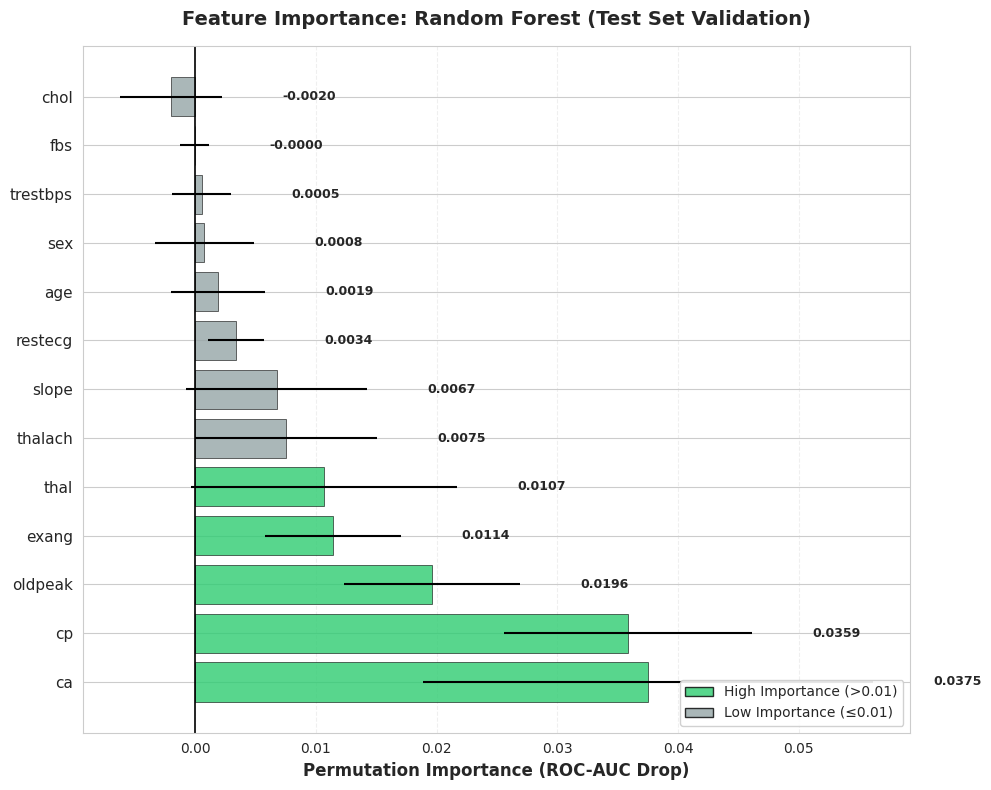


 Permutation importance visualization complete


In [65]:
# ============================================================================
# 8.2: PERMUTATION FEATURE IMPORTANCE (TEST SET)
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8.2: PERMUTATION FEATURE IMPORTANCE ANALYSIS")
print("=" * 80)

from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("\n Computing permutation importance (this may take 20-30 seconds)...")

# Calculate permutation importance on TEST SET with fixed random_state
perm_importance_rf = permutation_importance(
    rf_tuned,
    X_test_scaled,
    y_test,
    n_repeats=30,  # 30 permutations for robust estimates
    random_state=42,  # ENSURES REPRODUCIBILITY
    scoring='roc_auc',
    n_jobs=-1
)

print(" Permutation importance computed")

# Create results DataFrame
feature_names = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
                 'restecg', 'thalach', 'exang', 'oldpeak',
                 'slope', 'ca', 'thal']

perm_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance_Mean': perm_importance_rf.importances_mean,
    'Importance_Std': perm_importance_rf.importances_std
}).sort_values('Importance_Mean', ascending=False).reset_index(drop=True)

print("\n" + "=" * 80)
print("PERMUTATION FEATURE IMPORTANCE RESULTS (TEST SET)")
print("=" * 80)

print("\n Ranked by Mean Importance:\n")
for i, row in perm_importance_df.iterrows():
    print(f"   {i+1:2d}. {row['Feature']:12s}  Importance: {row['Importance_Mean']:6.4f}  (±{row['Importance_Std']:5.4f})")

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))

# Sort for plotting
sorted_idx = perm_importance_rf.importances_mean.argsort()[::-1]
sorted_features = [feature_names[i] for i in sorted_idx]
sorted_importances = perm_importance_rf.importances_mean[sorted_idx]
sorted_std = perm_importance_rf.importances_std[sorted_idx]

# Create bar plot with error bars
colors = ['#2ecc71' if imp > 0.01 else '#95a5a6' for imp in sorted_importances]
bars = ax.barh(range(len(sorted_features)), sorted_importances,
               xerr=sorted_std, color=colors, alpha=0.8, edgecolor='black', linewidth=0.5)

ax.set_yticks(range(len(sorted_features)))
ax.set_yticklabels(sorted_features, fontsize=11)
ax.set_xlabel('Permutation Importance (ROC-AUC Drop)', fontsize=12, fontweight='bold')
ax.set_title('Feature Importance: Random Forest (Test Set Validation)',
             fontsize=14, fontweight='bold', pad=15)
ax.axvline(x=0, color='black', linestyle='-', linewidth=1.2)
ax.grid(axis='x', alpha=0.3, linestyle='--')

# Add value labels
for i, (bar, imp, std) in enumerate(zip(bars, sorted_importances, sorted_std)):
    width = bar.get_width()
    ax.text(width + std + 0.005, bar.get_y() + bar.get_height()/2,
            f'{imp:.4f}', ha='left', va='center', fontsize=9, fontweight='bold')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', alpha=0.8, edgecolor='black', label='High Importance (>0.01)'),
    Patch(facecolor='#95a5a6', alpha=0.8, edgecolor='black', label='Low Importance (≤0.01)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10, framealpha=0.9)

plt.tight_layout()
plt.show()

print("\n Permutation importance visualization complete")



STEP 8.3: DETAILED CONFUSION MATRIX ANALYSIS

 CONFUSION MATRIX:

                Predicted
              No Disease  Disease
   Actual
   No Disease      28          5     (Total: 33)
   Disease          2         26     (Total: 28)
                ─────────────────
   Total           30         31     (Total: 61)

 PERFORMANCE BREAKDOWN:
    True Positives (TP):    26  - Diseased patients correctly identified
    True Negatives (TN):    28  - Healthy patients correctly identified
    False Positives (FP):    5  - Healthy patients misclassified as diseased
    False Negatives (FN):    2  - Diseased patients missed (CRITICAL ERROR)

 DERIVED METRICS:
   Sensitivity (Recall):           92.86%  (26/28 diseased detected)
   Specificity:                    84.85%  (28/33 healthy identified)
   Positive Predictive Value (PPV): 83.87%  (26/31 positive predictions correct)
   Negative Predictive Value (NPV): 93.33%  (28/30 negative predictions correct)
   Accuracy:                       88.5

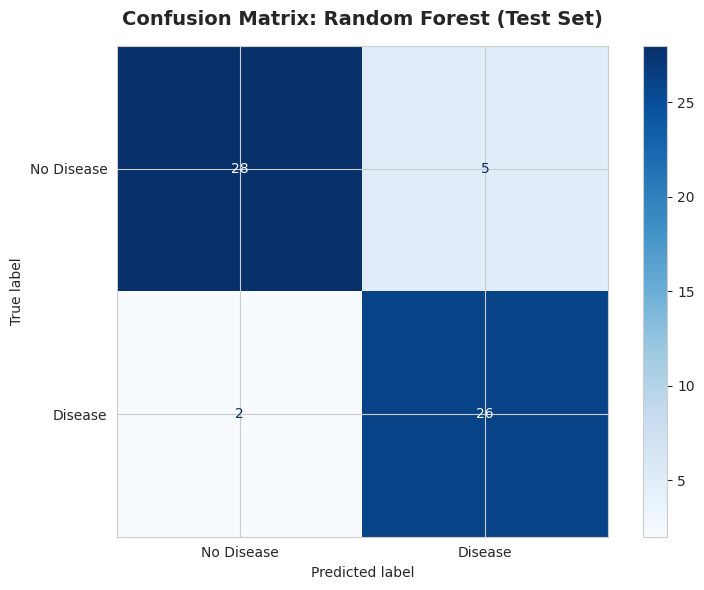


 Confusion matrix analysis complete


In [66]:
# ============================================================================
# 8.3: CONFUSION MATRIX ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8.3: DETAILED CONFUSION MATRIX ANALYSIS")
print("=" * 80)

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Convert to numpy arrays
y_test_array = y_test.values if hasattr(y_test, 'values') else y_test
y_test_array = np.array(y_test_array)

# Get predictions
X_test_array = X_test_scaled.values if hasattr(X_test_scaled, 'values') else X_test_scaled
X_test_array = np.array(X_test_array)

y_pred_rf = rf_tuned.predict(X_test_array)
y_proba_rf = rf_tuned.predict_proba(X_test_array)[:, 1]

# Confusion matrix
cm = confusion_matrix(y_test_array, y_pred_rf)
tn, fp, fn, tp = cm.ravel()

print("\n CONFUSION MATRIX:")
print(f"\n                Predicted")
print(f"              No Disease  Disease")
print(f"   Actual")
print(f"   No Disease    {tn:4d}       {fp:4d}     (Total: {tn+fp})")
print(f"   Disease       {fn:4d}       {tp:4d}     (Total: {fn+tp})")
print(f"                ─────────────────")
print(f"   Total         {tn+fn:4d}       {fp+tp:4d}     (Total: {len(y_test_array)})")

print(f"\n PERFORMANCE BREAKDOWN:")
print(f"    True Positives (TP):   {tp:3d}  - Diseased patients correctly identified")
print(f"    True Negatives (TN):   {tn:3d}  - Healthy patients correctly identified")
print(f"    False Positives (FP):  {fp:3d}  - Healthy patients misclassified as diseased")
print(f"    False Negatives (FN):  {fn:3d}  - Diseased patients missed (CRITICAL ERROR)")

print(f"\n DERIVED METRICS:")
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
ppv = tp / (tp + fp)
npv = tn / (tn + fn)
accuracy = (tp + tn) / (tp + tn + fp + fn)

print(f"   Sensitivity (Recall):           {sensitivity:.2%}  ({tp}/{tp+fn} diseased detected)")
print(f"   Specificity:                    {specificity:.2%}  ({tn}/{tn+fp} healthy identified)")
print(f"   Positive Predictive Value (PPV): {ppv:.2%}  ({tp}/{tp+fp} positive predictions correct)")
print(f"   Negative Predictive Value (NPV): {npv:.2%}  ({tn}/{tn+fn} negative predictions correct)")
print(f"   Accuracy:                       {accuracy:.2%}  ({tp+tn}/{len(y_test_array)} total correct)")

# Visualize confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Disease', 'Disease'])
disp.plot(cmap='Blues', ax=ax, values_format='d')
ax.set_title('Confusion Matrix: Random Forest (Test Set)', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()

print("\n Confusion matrix analysis complete")


In [67]:
# ============================================================================
# 8.4: INDIVIDUAL ERROR CASE ANALYSIS
# ============================================================================

print("\n" + "=" * 80)
print("STEP 8.4: DETAILED ERROR ANALYSIS")
print("=" * 80)

# Identify error cases
fp_indices = np.where((y_test_array == 0) & (y_pred_rf == 1))[0]
fn_indices = np.where((y_test_array == 1) & (y_pred_rf == 0))[0]

print(f"\n🔍 ERROR CASE SUMMARY:")
print(f"   False Positives: {len(fp_indices)} cases")
print(f"   False Negatives: {len(fn_indices)} cases")

# Analyze False Positives
if len(fp_indices) > 0:
    print(f"\n" + "=" * 80)
    print(f" FALSE POSITIVE ANALYSIS ({len(fp_indices)} cases)")
    print("=" * 80)
    print(f"\nHealthy patients incorrectly classified as diseased:\n")

    for i, idx in enumerate(fp_indices, 1):
        print(f"   {i}. Patient #{idx}:")
        print(f"      Predicted Probability: {y_proba_rf[idx]:.3f} (>0.5 threshold)")
        print(f"      Actual: NO DISEASE | Predicted: DISEASE")

        # Show patient features
        patient_features = X_test_array[idx]
        print(f"      Key Features (Standardized):")
        for j, fname in enumerate(feature_names):
            if fname in ['thal', 'ca', 'cp', 'oldpeak', 'exang']:  # Top important features
                print(f"         {fname:12s}: {patient_features[j]:6.2f}")
        print()

# Analyze False Negatives
if len(fn_indices) > 0:
    print(f"\n" + "=" * 80)
    print(f" FALSE NEGATIVE ANALYSIS ({len(fn_indices)} cases) - CRITICAL")
    print("=" * 80)
    print(f"\nDiseased patients missed by model:\n")

    for i, idx in enumerate(fn_indices, 1):
        print(f"   {i}. Patient #{idx}:")
        print(f"      Predicted Probability: {y_proba_rf[idx]:.3f} (<0.5 threshold)")
        print(f"      Actual: DISEASE | Predicted: NO DISEASE")

        # Show patient features
        patient_features = X_test_array[idx]
        print(f"      Key Features (Standardized):")
        for j, fname in enumerate(feature_names):
            if fname in ['thal', 'ca', 'cp', 'oldpeak', 'exang']:  # Top important features
                print(f"         {fname:12s}: {patient_features[j]:6.2f}")
        print()

print("=" * 80)
print(" ERROR ANALYSIS COMPLETE")
print("=" * 80)



STEP 8.4: DETAILED ERROR ANALYSIS

🔍 ERROR CASE SUMMARY:
   False Positives: 5 cases
   False Negatives: 2 cases

 FALSE POSITIVE ANALYSIS (5 cases)

Healthy patients incorrectly classified as diseased:

   1. Patient #1:
      Predicted Probability: 0.606 (>0.5 threshold)
      Actual: NO DISEASE | Predicted: DISEASE
      Key Features (Standardized):
         cp          :   0.87
         exang       :  -0.70
         oldpeak     :   1.16
         ca          :  -0.69
         thal        :   0.67

   2. Patient #17:
      Predicted Probability: 0.510 (>0.5 threshold)
      Actual: NO DISEASE | Predicted: DISEASE
      Key Features (Standardized):
         cp          :  -2.21
         exang       :  -0.70
         oldpeak     :  -0.80
         ca          :   0.45
         thal        :  -0.88

   3. Patient #20:
      Predicted Probability: 0.593 (>0.5 threshold)
      Actual: NO DISEASE | Predicted: DISEASE
      Key Features (Standardized):
         cp          :   0.87
        